### Imports

In [28]:
import os
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.special import gammaln
from sklearn.model_selection import GroupKFold
from scipy import stats
import matplotlib.pyplot as plt

### Read files

In [29]:
X_train = pd.read_csv('X_train.csv',index_col='ROW_ID')
y_train = pd.read_csv('y_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('X_test.csv',index_col='ROW_ID')

### Initial exploration

In [30]:
print(X_train.head(3)) # print the data structure to double check, some NaN are present

               TS     ALLOCATION    RET_20    RET_19    RET_18    RET_17  \
ROW_ID                                                                     
0       DATE_0001  ALLOCATION_01 -0.018192 -0.000306 -0.006881 -0.002393   
1       DATE_0001  ALLOCATION_02 -0.006394 -0.001059  0.001565  0.000033   
2       DATE_0001  ALLOCATION_03 -0.016587 -0.004517 -0.005306  0.004314   

          RET_16    RET_15    RET_14    RET_13  ...  SIGNED_VOLUME_8  \
ROW_ID                                          ...                    
0       0.000507 -0.001270 -0.002539  0.002830  ...         0.818730   
1       0.002829  0.001725  0.000875 -0.002160  ...        -1.390336   
2       0.006471 -0.005868 -0.005030 -0.001488  ...         0.961318   

        SIGNED_VOLUME_7  SIGNED_VOLUME_6  SIGNED_VOLUME_5  SIGNED_VOLUME_4  \
ROW_ID                                                                       
0              0.941014         0.714129        -0.323847         0.525097   
1             -0.651784 

In [31]:
print(X_test.head(3)) # same situations

               TS     ALLOCATION    RET_20    RET_19    RET_18    RET_17  \
ROW_ID                                                                     
527073  DATE_2523  ALLOCATION_01 -0.000523  0.000066 -0.001601  0.002030   
527074  DATE_2523  ALLOCATION_02  0.002868 -0.000870  0.000609  0.003156   
527075  DATE_2523  ALLOCATION_03 -0.000435  0.003141  0.001410 -0.011531   

          RET_16    RET_15    RET_14    RET_13  ...  SIGNED_VOLUME_8  \
ROW_ID                                          ...                    
527073 -0.000137 -0.001506  0.000479 -0.001006  ...        -1.124653   
527074  0.001140  0.000728  0.002079  0.000126  ...        -1.310546   
527075 -0.000685  0.002088 -0.003898  0.008467  ...         1.402281   

        SIGNED_VOLUME_7  SIGNED_VOLUME_6  SIGNED_VOLUME_5  SIGNED_VOLUME_4  \
ROW_ID                                                                       
527073        -1.263611        -1.177919        -1.251840        -1.242161   
527074        -0.925154 

In [32]:
print(y_train.head(3)) # fast print check on target data structure

          target
ROW_ID          
0       0.009210
1       0.000405
2       0.005967


In [33]:
print(X_train.shape, X_test.shape) # look at the shape of the data
print("portfolios:", X_train["ALLOCATION"].nunique(), X_test["ALLOCATION"].nunique()) # 
# we have the same number of portfolio 278 and same number of columns in each database, good.

(527073, 44) (31870, 44)
portfolios: 278 278


In [34]:
X_train["target"] = y_train["target"]      # we attach the next-day return to each row
print("share of up days:", (X_train["target"] > 0).mean().round(4)) # we see how often we have up and down days

share of up days: 0.5072


In [35]:
RET = [f"RET_{i}" for i in range(1, 21)]   # RET_1 = most recent day
# look at the number of Nan, i.e., missing days. We will have to deal with them
print("missing RET values: train", X_train[RET].isna().sum().sum(), " test", X_test[RET].isna().sum().sum()) 

missing RET values: train 262  test 294


Some plots before moving on to sorting our data. It is always a good thing to look at some properties visually before anything else.

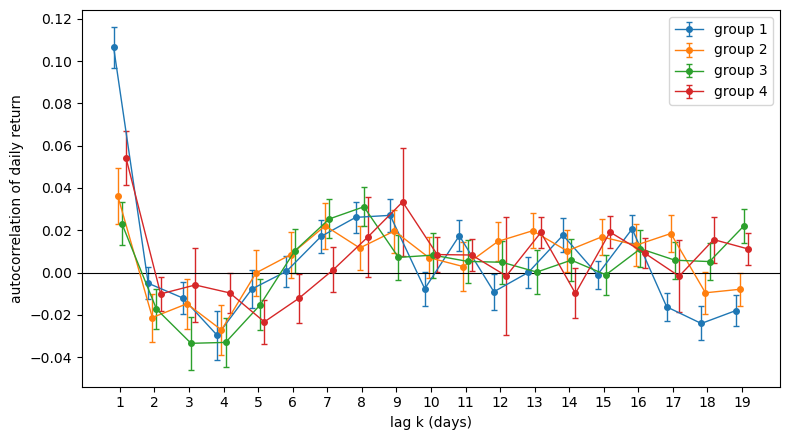

In [36]:
# Look at auto-correlation of lag k days divided between the various groups 

alloc = X_train["ALLOCATION"].to_numpy()
grp_of_alloc = X_train.groupby("ALLOCATION")["GROUP"].first()
lags = range(1, 20)
acf_raw = {}
for k in lags:
    a, b = R[:, :20 - k], R[:, k:]              # pairs k days apart inside each row
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = np.where(ok, a, 0), np.where(ok, b, 0)
    t = pd.DataFrame({"ab": (a * b).sum(1), "aa": (a * a).sum(1), "bb": (b * b).sum(1)}).groupby(alloc).sum()
    per_p = t["ab"] / np.sqrt(t["aa"] * t["bb"])
    for g, v in per_p.groupby(grp_of_alloc.reindex(per_p.index)):
        acf_raw[(g, k)] = (v.mean(), v.std() / np.sqrt(len(v)))

fig, ax = plt.subplots(figsize=(8, 4.5))
for j, g in enumerate(sorted(grp_of_alloc.unique())):
    m  = np.array([acf_raw[(g, k)][0] for k in lags])
    se = np.array([acf_raw[(g, k)][1] for k in lags])
    ax.errorbar(np.array(lags) + (j - 1.5) * 0.12, m, yerr=2 * se, fmt="o-", ms=4, lw=1, capsize=2, label=f"group {g}")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(list(lags)); ax.set_xlabel("lag k (days)"); ax.set_ylabel("autocorrelation of daily return")
ax.legend(); plt.tight_layout(); plt.show()

We see that a small positive lag-1 autocorrelation is present for each group, with group 1 being firmly separated from the others. We then have a negativly correlated group of eraly lag-k days for the curve to eventually really settle about zero from above. However, we must stress that the error bars are not really reliable as overlapping windows count the same days multiple times (we will deal with this shortly).

The take-away message here is however that we cannot expect a big edge (I mean obviosly). To wit, even the strongest autocorrelation is quite small.

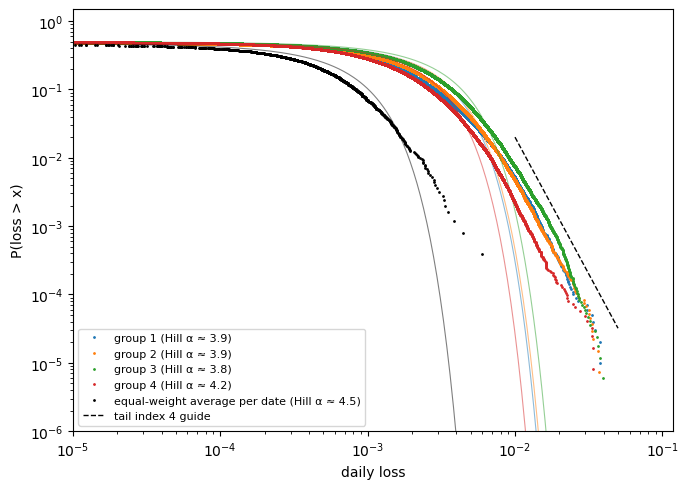

In [37]:
# How fat tailed is the market? We look at the left tail

def hill(loss, frac=0.01):                      # quick and most likely inaccurate Hill estimate
    x = np.sort(loss[loss > 0])[::-1]
    k = max(int(frac * len(x)), 10)
    return 1 / np.mean(np.log(x[:k] / x[k]))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
series = [(X_train.loc[X_train["GROUP"] == g, "RET_1"].to_numpy(), f"group {g}", c)
          for g, c in zip(sorted(X_train["GROUP"].unique()), colors)]
series.append((X_train.groupby("TS")["RET_1"].mean().to_numpy(), "equal-weight average per date", "k"))

for r, label, c in series:
    r = r[np.isfinite(r)]
    loss = np.sort(-r); sf = 1 - np.arange(len(loss)) / len(loss); m = loss > 0
    ax.loglog(loss[m], sf[m], ".", ms=2, color=c, label=f"{label} (Hill α ≈ {hill(-r):.1f})")
    xs = np.logspace(np.log10(loss[m].min()), np.log10(loss.max()), 300)
    ax.loglog(xs, stats.norm.sf(xs, loc=-r.mean(), scale=r.std()), "-", lw=0.8, color=c, alpha=0.5)

xg = np.array([0.01, 0.05]); ax.loglog(xg, 2e-2 * (xg / 0.01) ** -4, "k--", lw=1, label="tail index 4 guide")
ax.set_xlim(1e-5, None); ax.set_ylim(1e-6, 1.5)
ax.set_xlabel("daily loss"); ax.set_ylabel("P(loss > x)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

OK. We are in a fat-taield market (again, quite expected to be honest). We have a tail exponent (estimated with a fast Hill method) of $\alpha \approx 4$ for all of the groups. As we have not worked out errors on our tail indeces we are not really going to discuss groups differences (although they might be there, and small changes in $\alpha$ can have big consequences). The difference between how this goes and a thin-tailed (Gaussian) world with same variance is shown by the continous lines by the way. Always nice to have a look at.

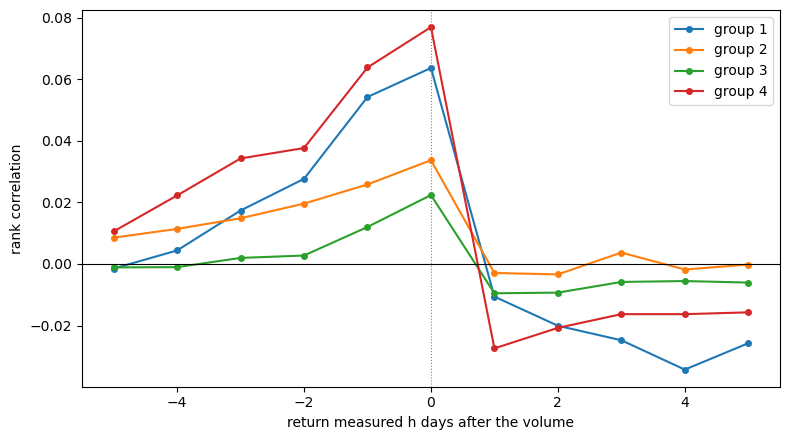

In [38]:
VOL = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]
R_ext = np.column_stack([X_train["target"].to_numpy(), X_train[RET].to_numpy()])   # col 0 = target, col i = RET_i
V = X_train[VOL].to_numpy()                                                          # col j-1 = SIGNED_VOLUME_j

pm = X_train.groupby("ALLOCATION")
R_ext = R_ext - np.column_stack([pm["target"].transform("mean")] + [pm[c].transform("mean") for c in RET])
V     = V - np.column_stack([pm[c].transform("mean") for c in VOL])

def to_rank(M):                                         # pooled rank transform, NaN kept
    flat = M.ravel(); r = np.full(flat.shape, np.nan); ok = np.isfinite(flat)
    r[ok] = stats.rankdata(flat[ok]); return r.reshape(M.shape)
Rr, Vr = to_rank(R_ext), to_rank(V)
grp = X_train["GROUP"].to_numpy()

hs = range(-5, 6)
fig, ax = plt.subplots(figsize=(8, 4.5))
for g in sorted(np.unique(grp)):
    rows = grp == g
    cc = []
    for h in hs:
        a, b = [], []
        for j in range(1, 21):                          # volume on the day of RET_j
            i = j - h                                   # the return h days later (0 = target)
            if 0 <= i <= 20:
                a.append(Vr[rows, j - 1]); b.append(Rr[rows, i])
        a, b = np.concatenate(a), np.concatenate(b); ok = np.isfinite(a) & np.isfinite(b)
        cc.append(np.corrcoef(a[ok], b[ok])[0, 1])
    ax.plot(list(hs), cc, "o-", ms=4, label=f"group {g}")
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("return measured h days after the volume")
ax.set_ylabel("rank correlation")
ax.legend(); plt.tight_layout(); plt.show()

OK. We plotted the signed volume vs return (lead–lag), demeaned per portfolio (i.e., before ranking, each return column and each volume column is demeaned by its portfolio's own full-sample mean). This removes *between-portfolio* differences, e.g., portfolios that are net bought on average and also have a lower average return. 

We see that before the volume ($h<0$) a steady ramp up to $h=0$** in every group (as in, trend-following money arrives *after* the move) peaking on the same day ($h=0$). Then something happens, and after the volume ($h>0$)we observe a sign flip, with clear differences between groups.

This is interesting, aside from return lags we see that *signed volume carries portfolio-level information about the next days' returns*. In particular, volume correlates *positively* with the same-day return but predicts the following days *negatively*, while the return lag predicts *positively*. This matches the classic picture that moves driven by heavy one-sided flow tend to reverse, while moves on light flow tend to persist.

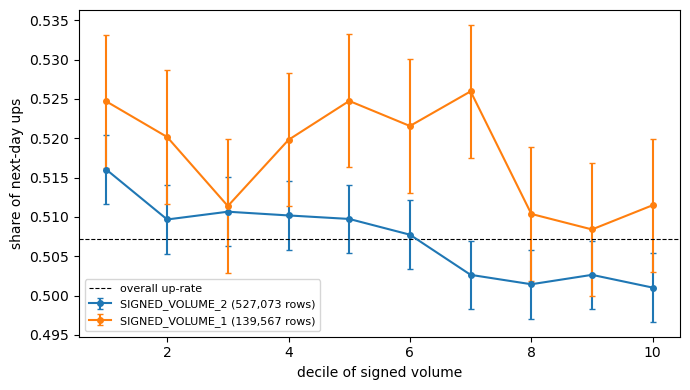

In [39]:
up = (X_train["target"] > 0).to_numpy()
fig, ax = plt.subplots(figsize=(7, 4))
for col, c in [("SIGNED_VOLUME_2", "tab:blue"), ("SIGNED_VOLUME_1", "tab:orange")]:
    v = X_train[col]; ok = v.notna().to_numpy()
    dec = pd.qcut(v[ok], 10, labels=False, duplicates="drop")
    rate = pd.Series(up[ok]).groupby(dec.to_numpy()).mean()
    n = pd.Series(up[ok]).groupby(dec.to_numpy()).size()
    ax.errorbar(rate.index + 1, rate, yerr=2 * np.sqrt(rate * (1 - rate) / n), fmt="o-", ms=4,
                capsize=2, color=c, label=f"{col} ({ok.sum():,} rows)")
ax.axhline(up.mean(), color="k", lw=0.8, ls="--", label="overall up-rate")
ax.set_xlabel("decile of signed volume")
ax.set_ylabel("share of next-day ups"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Above we are looking at the next-day up-rate by decile of signed volume. We see that whilst SIGNED_VOLUME_2 decays almost monotonically, SIGNED_VOLUME_1 is much noiser and with no clear trend. Interestingly, the trend in SIGNED_VOLUME_2 is *contrarian*, i.e., heavy buying two days before the target day goes with fewer up-days. Luckily, this is consistent with the negative $h>0$ correlations above. Of course, once again, the slope is less significant that how it looks on account of treating the rows as independent. 

### Data cleaning & sorting

Here, the idea is relatively simple but it is quite important that we execute it properly. 

Primo. We are looking at returns in 20 days window and trying to predict the sign (i.e., up or down) of the next day. For each portfolio, of course.

Secondo, we note that for each portfolio tomorrow's row in our database (if present) should hold today's return shifted by one slot. To wit, today's RET_1 $\sim$ RET_2 of tomorrow, today's RET_2 $\sim$ RET_3 of tomorrow, and so on. The match is assumed to be approximate, not exact, due to the drift in the portfolio allocation through each day. 

Therefore, we have a non-trivial issue. We would like to work with a **honest train/validation split** but this would be quite hard as it is right now. Indeed, a row's target (tomorrow's return) appears as RET_1 in the next date's row. Thus, if we were to split dates at random then every validation date would have its neighbours in the training set. The trained model would effectively "see" part of the answer. *This is not allowed, of course. It would inflate  the validation score of the model with no real merit.*

Also, it is not a bad idea to possibly have time-varying parameters given the non-stationarity of the markets. So there is that too.

We thus try to build longer windows of data by looking at rows whose shifted windows matches another one. We expect to find some, but not all.

In [40]:
# We begin by looking at a single portfolio
overlap = 15 # number of days we compare (robust under tuning)
g = X_train[X_train["ALLOCATION"] == "ALLOCATION_01"]
R = np.nan_to_num(g[RET].to_numpy()) # the rows, i.e., the dates of the portfolio

today = R[:,0:overlap]        # RET 1 - 15
tomorrow = R[:,1:overlap+1]   # RET 2 - 16

# Since we expect drifts, a good practice is to normalise our windows
epsilon = 1e-12  # to avoid divergences
today = today/(np.linalg.norm(today, axis =1, keepdims = True) + epsilon)
tomorrow = tomorrow/(np.linalg.norm(tomorrow, axis =1, keepdims = True) + epsilon)

# we then extract the 2 rows whose shifted window is closest

dist, idx = cKDTree(tomorrow).query(today, k =2)

# if we have a clear winner
ratio = 0.3     # robust under tuning given the follow up steps
clear = dist[:,0] < ratio*dist[:,1]
print("rows:", len(g), "| rows with a clear next-day match:", clear.sum())


# let us look at a few matches to make sure 
m = pd.DataFrame({
    "date": g["TS"].values,
    "next_date": g["TS"].values[idx[:, 0]],
    "RET_1 today": g["RET_1"].values,
    "RET_2 of match": g["RET_2"].values[idx[:, 0]],
    "clear": clear,
})
print(m[m["clear"]].head(10))

rows: 1431 | rows with a clear next-day match: 1131
         date  next_date  RET_1 today  RET_2 of match  clear
0   DATE_0001  DATE_0404     0.003944        0.003131   True
2   DATE_0005  DATE_2141     0.005628        0.006723   True
3   DATE_0007  DATE_1332    -0.003151       -0.005836   True
4   DATE_0010  DATE_0343     0.005724        0.005943   True
5   DATE_0014  DATE_2494    -0.002946       -0.003865   True
6   DATE_0015  DATE_2501    -0.001909       -0.002236   True
8   DATE_0017  DATE_1488    -0.000375        0.001183   True
9   DATE_0019  DATE_2048    -0.001959       -0.003233   True
10  DATE_0023  DATE_1617     0.001064        0.000818   True
11  DATE_0026  DATE_1312     0.000855        0.001245   True


In [41]:
# We run for one portfolio to check it made sense, now 
# we build a function.

def next_day_votes(X, k=1, overlap = 15, ratio = 0.3):
    # For every portfolio, each row votes for the date whose row looks like shifted by k days.
    # Returns one vote per each clear match (TS --> next TS)
    votes = []
    for a, g in X.groupby("ALLOCATION"):
        R = np.nan_to_num(g[RET].to_numpy()) 
        original = R[:,0:overlap]/(np.linalg.norm(R[:,0:overlap])+epsilon)      
        shifted  = R[:,k:overlap+k]/(np.linalg.norm(R[:,k:overlap+k])+epsilon)      
        d, j = cKDTree(shifted).query(original, k =2)
        clear = d[:,0] < ratio*d[:,1]
        votes.append(pd.DataFrame({"ALLOCATION": a, "TS":g["TS"].values[clear],"NEXT_TS": g["TS"].values[j[clear,0]]}))
    return pd.concat(votes, ignore_index = True)

votes = next_day_votes(X_train, k=1, overlap=overlap, ratio= ratio)

# let us look at what we got, clear number of votes, how many recieved a vote etc. etc.
print("rows:", len(X_train), "| clear votes:", len(votes), f"({len(votes) / len(X_train):.1%})")
print("dates that received at least one vote:", votes["TS"].nunique(), "of", X_train["TS"].nunique())
print(votes.head())

rows: 527073 | clear votes: 391435 (74.3%)
dates that received at least one vote: 2519 of 2522
      ALLOCATION         TS    NEXT_TS
0  ALLOCATION_01  DATE_0001  DATE_0404
1  ALLOCATION_01  DATE_0005  DATE_2141
2  ALLOCATION_01  DATE_0007  DATE_1332
3  ALLOCATION_01  DATE_0010  DATE_0343
4  ALLOCATION_01  DATE_0014  DATE_2494


In [42]:
# Now we have to turn the votes into links between dates

def pick_links(votes, min_votes = 10):
    # we keep a match only if enough portfolios agree (i.e., the majority), and no
    # other date claims the same next date
    n = votes.groupby(["TS","NEXT_TS"]).size().rename("n").reset_index() # introduce n column essentially
    n["share"] = n["n"]/n.groupby("TS")["n"].transform("sum")   # extract share
    best = n.sort_values("n", ascending=False).drop_duplicates("TS")       # top candidate per date
    best = best[(best["n"]>min_votes) & (best["share"]>0.5)]
    best.drop_duplicates("NEXT_TS", keep = False)
    return dict(zip(best["TS"], best["NEXT_TS"])), n 

links, vote_table = pick_links(votes)

print("dates with a kept link:", len(links), "of", X_train["TS"].nunique())

# all good but are the majorities actually fragile? 
top = vote_table.sort_values("n", ascending=False).drop_duplicates("TS")
print("share of votes for the winner, quantiles:", top["share"].quantile([0.05, 0.25, 0.5]).round(2).to_dict())


dates with a kept link: 2499 of 2522
share of votes for the winner, quantiles: {0.05: 0.75, 0.25: 1.0, 0.5: 1.0}


We see that even the weakest 5% of winners took 75% of their date's votes, so most links are clear-cut. The aggregation and vote by majority seems robust.

But we have no trust nonetheless and we want to check our links. We remark that if date $i$ follows date $j$, then each portfolio's return on $j$ should show up as its RET_2 on $i$. These should line up between $i$ and $j$ across all the portfolios the two dates share.

How do we test this? Like this: (i) we compute the Spearman (rank) correlation between the shared portfolio and multiply by $\sqrt{n}$; (ii) we keep a link if it reaches a $5\sigma$ signficance (particle physics dictates here) with respect to the $\mathcal{N}(0,1)$ expecation of a random null. Also, note that here we employ the Spearman to avoid the rare fat-tailed days to fully determine the results. Fat-tails are crucial in delaing with markets but here we want to look at a bulk properties so we weight them down. Also, we only consider cases in which at least 10 portfolios are available. Below is counting crisps.

In [43]:
def verify_links(links, k, X, min_z =5.0):
    # we create a small table per date, indexed by portoflio
    by_date = {t: g.set_index("ALLOCATION") for t, g in X.groupby("TS")}
    good, zs = {}, {}
    for t, u in links.items():
        a = by_date[t]["RET_1"]                         # day t's return
        b = by_date[u][f"RET_{k+1}"].reindex(a.index)   # same day but seen from the u date
        m = a.notna() & b.notna() # deal with nan
        n = m.sum()
        if n>= 10:
            z = a[m].corr(b[m], method = "spearman")*np.sqrt(n)
            zs[t] = z
            if z >= min_z:
                good[t] = u 
    print(f"shift {k}: {len(links)} candidate links, {len(good)} pass (z >= {min_z})")
    return good, pd.Series(zs)

links_ok, z = verify_links(links, k=1, X=X_train)
print(z.describe())
print("weakest links:\n", z.nsmallest(5))

shift 1: 2499 candidate links, 2485 pass (z >= 5.0)
count    2499.000000
mean       12.836398
std         3.305644
min         1.652326
25%        10.945831
50%        13.778941
75%        15.691396
max        16.471573
dtype: float64
weakest links:
 DATE_0474    1.652326
DATE_0500    1.837198
DATE_0449    1.856362
DATE_2423    3.407836
DATE_1811    4.133585
dtype: float64


Our test has identified a handful of weak links. However, the majority are quite strong with (median $z \approx 13.8$) and very little below $z = 5$ overall. We can therefore reject the small minority and keep the large majority quite safely.

We can now build the stratches of time of consecutive dates.

In [44]:
def build_chains(nxt,step):
    chains = []
    starts = set(nxt) - set(nxt.values()) # dates with to precedent day
    for s in starts:
        c, pos = [s], [0]
        while c[-1] in nxt:
            assert len(c) <= X_train["TS"].nunique(), f"loop detected from {s}" # check if we failed in the link constructions 
            pos.append(pos[-1] - step[c[-1]])
            c.append(nxt[c[-1]])
        chains.append((c, pos))
    chains.sort(key=lambda cp: -len(cp[0]))   # longest first
    return chains

nxt  = dict(links_ok) # only the approved links
step = {t: 1 for t in nxt}
chains = build_chains(nxt, step)

lengths = [len(c) for c, _ in chains]
placed  = {d for c, _ in chains for d in c}
print("stretches:", len(chains))
print("longest 10:", lengths[:10])
print("dates placed:", len(placed), "of", X_train["TS"].nunique())
print("dates in links but not placed (would mean a loop):", len(set(nxt) - placed))

stretches: 51
longest 10: [245, 222, 184, 183, 177, 168, 166, 162, 141, 130]
dates placed: 2518 of 2522
dates in links but not placed (would mean a loop): 0


We have (i) no loops (badl links creeping in), (ii) very good placements. So we can keep going onto **bridging**.

Essentially, a stretch of consecutive days (as we built them from above) can end either because the next day is not in our data or because a link failed the $5\sigma$ check. And yet, it is fully possible that the end oa stretch and the start of another are just $k$ days apart. In case, that is still important information of course. 

How do we go about this? 

- We only look at the links from the end to the start of stretches (reduces the search);
- We lower to overlap = 10 so that we can probe confortably up to high shifts;
- Impose an aboslute cut on the distance between the stretches, i.e, cosine similarity of at least $97\%$;
-  We raise the minimum number of votes up (bigger claim);
- Still we impose the $5\sigma$ bit;
- We forbid loops;
- We re-add the single dates as one-day stretches to see if we can still link the up.

In [45]:
def all_chains(nxt, step, all_dates): # build all of the chains
    chains = build_chains(nxt,step)
    placed = {d for c, _ in chains for d in c} # dates which have been placed
    chains += [([d], [0]) for d in all_dates if d not in placed] # lone dates
    return chains

def unit(M): # to normalise
    return M/(np.linalg.norm(M, axis = 1 , keepdims= True) + epsilon)

def bridge_votes(X,k,from_dates,to_dates,overlap=10,max_dist =0.25): 
    # keep only candidate "from" dates and group the possible "to" dates by portfolio.
    From = X[X["TS"].isin(from_dates)]
    To = dict(tuple(X[X["TS"].isin(to_dates)].groupby("ALLOCATION")))
    votes =[]
    for a, gf in From.groupby("ALLOCATION"): 
        if a not in To:  # only compare portfolios that exist on both sides.
            continue
        gt = To[a]
        this = unit(np.nan_to_num(gf[RET].to_numpy()[:,0:overlap]))
        shifted = unit(np.nan_to_num(gt[RET].to_numpy()[:,k:overlap+k]))
        d, j = cKDTree(shifted).query(this, k=1)
        # keep only sufficiently close matches as valid bridge votes.
        ok = d < max_dist
        # record the proposed date-to-date links for the matching windows.
        votes.append(pd.DataFrame({"TS": gf["TS"].values[ok], "NEXT_TS":gt["TS"].values[j[ok]]}))
    return pd.concat(votes, ignore_index=True)

In [46]:
all_dates = X_train["TS"].unique()
chains = all_chains(nxt, step, all_dates)

In [47]:
# We cycle over increasingly long shifts to bridge gaps of k days.
for k in range(2,6):
    # identify the current end and start date of each chain
    end_of = {c[-1]: i for i, (c,_) in enumerate(chains)}
    start_of = {c[0]: i for i, (c,_) in enumerate(chains)}
    # generate portfolio-level votes for possible k-day bridges.
    v = bridge_votes(X_train, k, set(end_of), set(start_of))
    v = v[v["TS"].map(end_of) != v["NEXT_TS"].map(start_of)]  # no loop allowed   
    cand, _ = pick_links(v, min_votes=30) # get the candidates
    new, zk = verify_links(cand, k, X_train, min_z=5.0) # verify those links at 5sigma
    for t, u in new.items():
        nxt[t] = u
        step[t] = k
    # reconstruct the chains after adding the new bridges.
    chains = all_chains(nxt, step, all_dates) # extract the chains 
    print(f"  after k={k}: {len(new)} bridges, {len(chains)} stretches")


lengths = sorted((len(c) for c, _ in chains), reverse=True)
print("longest 10:", lengths[:10])
print("stretches with >= 20 dates:", sum(l >= 20 for l in lengths))

shift 2: 1 candidate links, 1 pass (z >= 5.0)
  after k=2: 1 bridges, 54 stretches
shift 3: 0 candidate links, 0 pass (z >= 5.0)
  after k=3: 0 bridges, 54 stretches
shift 4: 1 candidate links, 1 pass (z >= 5.0)
  after k=4: 1 bridges, 53 stretches
shift 5: 0 candidate links, 0 pass (z >= 5.0)
  after k=5: 0 bridges, 53 stretches
longest 10: [245, 238, 200, 183, 182, 181, 177, 168, 162, 157]
stretches with >= 20 dates: 41


So, we recover some new links, good that we checked. Before moving on, one final check with respect to our previous pipeline. We re-try 1-day shift links only from stretches end to strecthes start. We may recover some links this way as the duplicate rule we imposed might have discarded some. Still with $5\sigma$ threshold of course.

In [48]:
print("the single k=2 candidate:", zk.to_dict())

end_of   = {c[-1]: i for i, (c, _) in enumerate(chains)}
start_of = {c[0]:  i for i, (c, _) in enumerate(chains)}
v1 = bridge_votes(X_train, 1, set(end_of), set(start_of), overlap=15, max_dist=0.25)
v1 = v1[v1["TS"].map(end_of) != v1["NEXT_TS"].map(start_of)]

print(v1.groupby(["TS", "NEXT_TS"]).size().nlargest(15))   # strongest end -> start pairs
cand1, _ = pick_links(v1, min_votes=30)
new1, z1 = verify_links(cand1, 1, X_train, min_z=5.0)
print(z1.sort_values())

the single k=2 candidate: {}
TS         NEXT_TS  
DATE_0746  DATE_0679    108
DATE_1663  DATE_1692    101
DATE_2482  DATE_1683     89
DATE_0449  DATE_2435     84
DATE_2337  DATE_0978     70
DATE_1059  DATE_0094     69
DATE_0093  DATE_2006     67
DATE_1539  DATE_2351     67
DATE_2261  DATE_2490     66
DATE_0500  DATE_2422     56
DATE_2423  DATE_0213     55
DATE_1539  DATE_0226     50
DATE_2097  DATE_0874     50
DATE_0738  DATE_2445     47
DATE_1059  DATE_0099     46
dtype: int64
shift 1: 17 candidate links, 12 pass (z >= 5.0)
DATE_2027     4.413103
DATE_1388     4.433437
DATE_2097     4.519163
DATE_0738     4.626989
DATE_0281     4.869254
DATE_0500     6.706016
DATE_1059     7.560901
DATE_1539     7.777549
DATE_1342     7.848692
DATE_2261     8.012111
DATE_0093     8.027281
DATE_2423     8.105743
DATE_2337     8.147024
DATE_0746    10.666926
DATE_2482    10.776836
DATE_1663    11.364317
DATE_0449    11.376323
dtype: float64


Bingo, we recovered some. We thus re-run the procedure after adding the rescued links.

In [49]:
# Add back our  rescued 1-day links
for t, u in new1.items():
    nxt[t] = u
    step[t] = 1
chains = all_chains(nxt, step, all_dates)
print("after rescue:", len(chains), "stretches")

# One more bridge pass (as the ends and starts have changed)
for k in range(2, 6):
    end_of   = {c[-1]: i for i, (c, _) in enumerate(chains)}
    start_of = {c[0]:  i for i, (c, _) in enumerate(chains)}
    v = bridge_votes(X_train, k, set(end_of), set(start_of), overlap=10, max_dist=0.25)
    v = v[v["TS"].map(end_of) != v["NEXT_TS"].map(start_of)]
    cand, _ = pick_links(v, min_votes=30)
    new, zk = verify_links(cand, k, X_train, min_z=5.0)
    for t, u in new.items():
        nxt[t] = u
        step[t] = k
    chains = all_chains(nxt, step, all_dates)
print("final:", len(chains), "stretches")

after rescue: 41 stretches
shift 2: 0 candidate links, 0 pass (z >= 5.0)
shift 3: 0 candidate links, 0 pass (z >= 5.0)
shift 4: 0 candidate links, 0 pass (z >= 5.0)
shift 5: 0 candidate links, 0 pass (z >= 5.0)
final: 41 stretches


In [50]:
# We now save our results as PIECE (stretch id, 0 = longest) and POS (day within the stretch)
chains.sort(key=lambda cp: -len(cp[0]))
order = {d: (p, pos) for p, (c, ps) in enumerate(chains) for d, pos in zip(c, ps)}
X_train["PIECE"] = X_train["TS"].map(lambda d: order[d][0])
X_train["POS"]   = X_train["TS"].map(lambda d: order[d][1])

In [51]:
# Sanity checks because we never trust 
sizes = X_train.groupby("PIECE")["TS"].nunique().sort_values(ascending=False)
print("longest 10:", sizes.head(10).tolist())
print("stretches >= 20 dates:", (sizes >= 20).sum(), "| lone dates:", (sizes == 1).sum())
assert X_train.groupby("TS")["PIECE"].nunique().max() == 1          # each date in one stretch
assert X_train.groupby(["PIECE", "POS"])["TS"].nunique().max() == 1 # no two dates share a slot

X_train.to_pickle(os.path.join("./", "train_sorted.pkl"))

longest 10: [248, 170, 150, 128, 109, 106, 104, 103, 94, 91]
stretches >= 20 dates: 33 | lone dates: 1


### Model Inputs: a return-only approach

We are going to build a **first** hierarchical Bayesian model to predict the returns sign given the previous 20 days returns. The first step is a decision on the inputs. We will employ **3 inputs per row**.

1. The **drift**, namely a portfolio's typical tendecy to go up 
2. The **fast signal** ($b_1$), i.e., yesterday's move RET_1/$s$ (clipped at $\pm 5$ to counter fat tails, still looking at the bulk here)
3. The **slower signal** ($b_2$) coming from the reset of the week, namely $\[\sum_{i=2}^5 \text{RET}$_$i\]/s$, still clipped at $\pm 5$. 

In all of these we have used $s := \text{std(20 days)}$, which is a volatility measure easily calculated also in the test set where no time stretches are build. We could have also used the median standard deviation or the mean absolute deviation to reduce the possible role of fat tails. Here, we went with clipping but either could have been implemented. 

Additionally, we will impose a *$1\%$ quantile floor from the training on $s$* to avoid blow-ups in the divisions. Additionally missing reutrn become $0$, i.e., missing information.

Before moving on to building these inputs, a couple of comments on these choices: 

1. Dividing by $s$ ensures that all portfolios (calm and wilds) can share a single prior within our choice of likelihood (we will use a Student-t, to be precise)
2. We are not going to implement all $20$ possible lags as we have already checked a few things which the reader should be made aware of: (a) a per-row correlation has a spread of about $0.22$, i.e., pure noise; (ii) trying RF and LightGBM on all 20 lags did not better our simple approach; and (iii) the structure is small (as we would expect!), namley lag-1 autocorrelation is of 0.04 and 0.11 in group 1 (plots docet).

In [52]:
def make_xy(X, vol_floor):
    s  = X[RET].std(axis=1).clip(lower=vol_floor)                      # row's own vol
    x1 = (X["RET_1"] / s).clip(-4, 4).fillna(0)
    x2 = (X[["RET_2", "RET_3", "RET_4", "RET_5"]].mean(axis=1) / s).clip(-4, 4).fillna(0)
    Z  = np.column_stack([np.ones(len(X)), x1, x2])                     # drift, x1, x2
    y  = (X["target"] / s).to_numpy() if "target" in X else None
    return Z, y, s.to_numpy()

vol_floor = X_train[RET].std(axis=1).quantile(0.01)     # fixed from training only
Z, y, s = make_xy(X_train, vol_floor)
Zt, _, st = make_xy(X_test, vol_floor)

In [53]:
# Sanity checks due to lack of trust engrained in me 
print("vol floor:", vol_floor)
print("share of x1 clipped:", np.mean(np.abs(Z[:, 1]) == 4), "| x2:", np.mean(np.abs(Z[:, 2]) == 4))
print("sign(y) == sign(target):", np.mean(np.sign(y) == np.sign(X_train["target"])))
print("y: mean %.3f  std %.3f  kurtosis %.1f" % (y.mean(), y.std(), pd.Series(y).kurt()))
beta = np.linalg.lstsq(Z, y, rcond=None)[0]      # pooled OLS, no hierarchy quick check
print("pooled OLS [drift, b1, b2]:", beta.round(4))
print("accuracy of sign(Z @ beta):", np.mean(np.sign(Z @ beta) == np.sign(y)))
print("To wit a correlation between prediction an outcome (via Shppard's formula) of:", np.sin(np.pi*(np.mean(np.sign(Z @ beta) == np.sign(y))-0.5)))

vol floor: 0.0008816691710766822
share of x1 clipped: 0.00014608982057513854 | x2: 0.0
sign(y) == sign(target): 1.0
y: mean 0.012  std 1.098  kurtosis 1.9
pooled OLS [drift, b1, b2]: [ 0.0106  0.0772 -0.016 ]
accuracy of sign(Z @ beta): 0.519787581606343
To wit a correlation between prediction an outcome (via Shppard's formula) of: 0.062124490359822905


Clearly, the clipping is not doing much. As expected. Good. The std is a bit above $s$ but on $20$ days we can expect some harmless fluctuations. Regrdless our model is going to work directly with std for portfolio so we do not need to worry about it. The kurtosis (which is greatly reduced with respect to the non-standardised data) still points to non Gaussian data, again as expected. This is a good reason to move to a t-student.

Let us then look at the result of the simple OLS fit. Well, we find (i) positive drift (most go up), (ii) a positive $b_1$, i.e., a short-term follow through, and (iii) a negative $b_2$ implying that the rest of the week shows a mild pull-back. Finally, looking at accuracy and implied correlation we see how a vanilla model already indicates the rough size of the edge. Small but present. 

We now move on to construct our model for real.

### The return-only model (HBM)

We model, for each row $i$ of a portfolio $p$ in a group $g$ the output as 

$$y_i = Z_i \cdot \theta_p + \sigma_p \epsilon_i \qquad \epsilon_i\, , \sim t_{\nu_g} \, ,$$

where we define 

$$
\begin{align*}

\theta_p &\sim \mathcal{N}(\theta_g +\gamma\,\text{turn}_p\,e_{b_1},\, \text{diag}\, [\tau^2])  \qquad &&\text{(portfolio level),} \\

\theta_g &\sim \mathcal{N}(\theta_0, \,\text{diag}\,[\omega^2])  \qquad &&\text{(group level),}\\

\theta_0 &\sim \mathcal{N}(0,1)\,, \quad \tau_k^2,\, \omega_k^2 \sim  \text{InvGamma}(2, 10^{-3})\,, \quad \gamma \sim \mathcal{N}(0,0.01) \qquad &&\text{(global level).}

\end{align*}$$

Here, a bit of definitions.

1. **Layer 1 (portfolio around group)**. We have the centre of each group as $\boldsymbol{\theta_g} = (\mu_g,\, b_{1,g},\, b_{2,g})$ with the typical drift and slopes of the portfolio (which are *estimated*), turn$_g$ is the portfolio's log median daily turnover standardised to mean $0$ and std $1$ (this is *known* as a covariate), $\gamma$ points to how much $b_1$ shifts per $1\sigma$ of turnover (single number, *estimated*, answer to the question "do more-traded portfolios have less follow-through"), $e_{b_1}$ is a fixed unit vector in $b_1$ direction, and $\tau_\mu,\, \tau_{b_1},\, \tau_{b_2}$ give the *typical distance of a portfolio from the group centre* (these are estimated). Note then that if portfolios really differ $\boldsymbol{\tau^2}$ comes out large and each portfolio relies more on its own $\boldsymbol{\theta}$, if not not evryone shrinks towards the group as diferences are just noise. 
2. **Layer 2 (group around global)**.  Here, $\boldsymbol{\theta_0}$ represent the global centre (i.e., the typical coefficients across all groups), whilst $\omega_\mu\, \omega_{b_1}, and \omega_{b_2}$ convey how far the group centers typically sit away from it.
3. **Layer 3 (the top)**. Here, we consider priors on the fixed numbers which are meant to say little. The prior on $\boldsymbol{\theta_0}$ (given the observed scales) essentially has little to no constraining power (good). The InvGamma$(2,10^{-3})$ is just the conjugate prior for a Gaussian variance with a selected long right tail to allow for larger spreads if the data select them, whilst the prior on $\gamma$ point to the expected small effect of the turnover (given that $b_1 \sim 0.08$). Note as well that after updating  $\boldsymbol{\tau^2}$ is fully data dominated, whilst $\boldsymbol{\tau^2}$ feels the pull of its prior but that is acceptable as the group centre is pinned down real well by about $\approx 70 \times 1900$ observations.

Of course, we have imposed some simplification in our modelling, e.g., applying a diagonalised covariance in the priors. However, the modelling is already relatively complex and we know the edge is small. As such, adding more parameters for little expected gain might just add complication not needed to our model. 

Some final remarks before moving on. Here, we are also applying priors InvGamma(2, 1) for the portfolio std and estimating per each group $\nu$ as the tail thickness cna differ by asset class. Finally we note that since a Student-t is just a Gaussian with random precision, we have 
$$ \epsilon_i = \frac{z_i}{\sqrt \lambda_i}\,, \qquad z_i \sim \mathcal{N}(0,1)\,, \qquad \lambda_i = \Gamma(\nu/2,\nu/2)\, .$$

We can then use **Gibbs sampling** as once $\lambda_i$ is given every other updates becomes a standard conjugate draw. 

Let us start getting this set-up going.

In [54]:
def setup(X, Z):
    # for one row per portfolio, we get its group and its typical turnover
    ptpb = X.groupby("ALLOCATION").agg(group=("GROUP", "first"), turnover=("MEDIAN_DAILY_TURNOVER", "median"))
    lt = np.log(ptpb["turnover"].clip(lower=1e-4))
    turn = ((lt - lt.mean()) / lt.std()).fillna(0).to_numpy()   # standardized log-turnover
    g_of_p = ptpb["group"].astype(int).to_numpy() - 1           # groups 0..3
    alloc_index = {k: i for i, k in enumerate(ptpb.index)}
    p = X["ALLOCATION"].map(alloc_index).to_numpy()             # portfolio index of each row
    return dict(A=len(ptpb), G=4, K=Z.shape[1], p=p, gp=g_of_p[p], g_of_p=g_of_p,
                n_p=np.bincount(p, minlength=len(ptpb)), turn=turn,
                alloc_index=alloc_index, e_b1=np.eye(Z.shape[1])[1])

S0 = setup(X_train, Z)
print("portfolios:", S0["A"], "| rows per portfolio (min/median/max):",
      S0["n_p"].min(), int(np.median(S0["n_p"])), S0["n_p"].max())
print("portfolios per group:", np.bincount(S0["g_of_p"]))
print("turnover z-scores: min %.2f  max %.2f" % (S0["turn"].min(), S0["turn"].max()))

portfolios: 278 | rows per portfolio (min/median/max): 19 1864 2439
portfolios per group: [70 70 70 68]
turnover z-scores: min -2.08  max 2.18


Everything seems reasonable, so we can move on and we begin setting up the Gibbs sampler. Let us start with the blocks that touch the data.

Primo, the tail weights $\lambda_i$. For Gamma priors and Gaussian likelihhod we have 
$$P(\lambda_i {|} r_i, \sigma_p, \nu) \sim \Gamma(\frac{1+\nu}{2}, \text{rate} = \frac{r_i^2/\sigma_p^2+\nu}{2})\, ,$$
where $r_i = y_i - Z_i\cdot\theta_p$ are the residual and for a typical day we expect $\lambda \approx 1$$, whilst a $5\sigma$ days would get (for \nu \approx 7) about $0.25$, i.e., is automatically downweighted. To wit, some robust regression with respect to fat tails.

Secondo, once the tail weights are known  we update the portfolio coefficients $\boldsymbol{\theta_p}$. We can write the *posterior precision matrix* as 

$$ P({\boldsymbol{\theta_p}}) =  P_p = \sum_{i\in p} w_iZ_iZ_i^T + \text{diag}[1/\boldsymbol{\tau^2}] \, ,$$

where the first sum is the *data precision* (namely, how much the data provide about the parameter) with weights given by $w_i := \lambda_i/\sigma_p^2$, whilst the second term is how much the prior provide. From this, as we can extract the posterior covariance $P({\theta_p})^{-1}$, we can get as well the posterior mean as 

$$ m_p = P_p^{-1} \left[\sum_{i\in p} w_iZ_iy_i + \text{diag}[1/\boldsymbol{\tau^2}]\, \big(\boldsymbol{\theta_g} + \gamma\,\mathrm{turn}_p\, e_{b_1}\big)\right] \, . $$

As we had priors and likelihood both Gaussian we then have 

$$ \theta_p \sim \mathcal{N}(m_p, P_p)\, .$$

In [55]:
def update_lambda(rng, y, Z, th_p, sig2, nu, S):
    p, gp = S["p"], S["gp"]
    r = y - np.einsum("ik,ik->i", Z, th_p[p])                          # residual of each row
    return rng.gamma((nu[gp] + 1) / 2, 2 / (nu[gp] + r**2 / sig2[p]))  # scale = 1/rate as numpy wants


def update_theta_p(rng, y, Z, lam, sig2, prior_mean, tau2, S):
    A, K, p = S["A"], S["K"], S["p"]
    w = lam / sig2[p]                                                  # weights
    XtWX = np.empty((A, K, K))
    XtWy = np.empty((A, K))
    for j in range(K):
        XtWy[:, j] = np.bincount(p, weights=w * Z[:, j] * y, minlength=A)   # now the argument y
        for k in range(j, K):
            XtWX[:, j, k] = XtWX[:, k, j] = np.bincount(p, weights=w * Z[:, j] * Z[:, k], minlength=A)
    P = XtWX + np.diag(1 / tau2)[None]                                 # posterior precision
    meanp = np.linalg.solve(P, (XtWy + prior_mean / tau2)[..., None])[..., 0]
    L = np.linalg.cholesky(P)
    xi = rng.standard_normal((A, K, 1))
    draw = meanp + np.linalg.solve(np.transpose(L, (0, 2, 1)), xi)[..., 0]   # m + L^{-T} xi
    return draw, meanp

In [56]:
# A quick test of the two updates with everything else held fixed, we are still missing some of the bits of course
rng = np.random.default_rng(0)
A, K, G = S0["A"], S0["K"], S0["G"]
nu    = np.full(G, 7.0)            # from the kurtosis estimate
sig2  = np.ones(A)
tau2  = np.full(K, 1e-3)           # tau about 0.03
theta_g = np.tile(beta, (G, 1))    # pooled OLS as every group's centre
gamma = 0.0
th_p  = np.tile(beta, (A, 1))

prior_mean = theta_g[S0["g_of_p"]] + gamma * S0["turn"][:, None] * S0["e_b1"]
for it in range(5):
    lam = update_lambda(rng, y, Z, th_p, sig2, nu, S0)
    th_p, m_p = update_theta_p(rng, y, Z, lam, sig2, prior_mean, tau2, S0)

r = y - np.einsum("ik,ik->i", Z, th_p[S0["p"]])
print("lambda quantiles:", np.quantile(lam, [0.001, 0.05, 0.5, 0.95]).round(3))
print("mean lambda for |r|>4:", lam[np.abs(r) > 4].mean().round(3), "| |r|<1:", lam[np.abs(r) < 1].mean().round(3))
print("b1 across portfolios (5/50/95%):", np.quantile(m_p[:, 1], [0.05, 0.5, 0.95]).round(4))

i = S0["n_p"].argmin()
own = np.linalg.lstsq(Z[S0["p"] == i], y[S0["p"] == i], rcond=None)[0]
print(f"smallest portfolio ({S0['n_p'][i]} rows): own OLS b1 {own[1]:.3f} | "
      f"prior b1 {prior_mean[i, 1]:.3f} | posterior b1 {m_p[i, 1]:.3f}")

lambda quantiles: [0.093 0.321 0.923 2.035]
mean lambda for |r|>4: 0.282 | |r|<1: 1.103
b1 across portfolios (5/50/95%): [0.0321 0.0686 0.113 ]
smallest portfolio (19 rows): own OLS b1 0.049 | prior b1 0.077 | posterior b1 0.081


OK, all seems in order. The $\lambda$ weights behave as intended with a median of 0.92, while extreme rows receive weights around 0.09 and tail rows average $0.28$ versus $1.10$ for typical rows. We can also see that across portfolios, $b_1$ shows substantial variation, with the middle $90\%$ spanning from $0.113$ to $0.032$ around $0.07$ despite fixing $\tau=0.03$. For the smallest portfolio, the posterior $b_1=0.081$ rmoves from the prior values of $0.077$ but with only 19 rows, the $\lambda$-weighted data can shift it from the group value quite easily.

We can move on to the rest of the updates needed. To cut a long story short, the posterior conditional (on all the other) distributions for our whole universe can be summarised by the following list, given that $A$ is the number of portfolios, $G=4$ is the number of groups, $n_p$ is the number of rows of portfolio $p$, and $N_g$ is the number of portfolios in group $g$. To wit:

1. **Portfolio noise** (the noise level of each portfolio, from its weighted residuals)

    $$
    \sigma_p^2 \mid \cdot \sim \mathrm{InvGamma}\!\left(2 + \frac{n_p}{2},\ 1 + \frac{1}{2}\sum_{i\in p}\lambda_i\, r_i^2\right)\, .
    $$

2. **Turnover effect** (regression of $b_{1,p} - b_{1,g}$ on turnover)

    $$
    \begin{aligned}
    & \gamma \mid \cdot \sim \mathcal{N}\!\left(m_\gamma,\ P_\gamma^{-1}\right)\,, \\
    & P_\gamma = \frac{\sum_p \mathrm{turn}_p^2}{\tau_{b_1}^2} + \frac{1}{0.01}\,, \\
    & m_\gamma = P_\gamma^{-1}\,\frac{\sum_p \mathrm{turn}_p\,\big(b_{1,p} - b_{1,g(p)}\big)}{\tau_{b_1}^2}\,.
    \end{aligned}
    $$

3. **Group centres** (component-wise precision-weighted average of the group's portfolios, pulled towards $\theta_0$)

    $$
    \begin{aligned}
    &\theta_g \mid \cdot \sim \mathcal{N}\!\left(m_g,\ \mathrm{diag}\!\left[P_g^{-1}\right]\right)\,, \\
    & P_g = \frac{N_g}{\tau^2} + \frac{1}{\omega^2}\,, \\
    &m_g = P_g^{-1}\left(\frac{\sum_{p\in g}\big(\theta_p - \gamma\,\mathrm{turn}_p\, e_{b_1}\big)}{\tau^2} + \frac{\theta_0}{\omega^2}\right)\, .
    \end{aligned}
    $$

4. **Global centre** (component average of the group centres, pulled towards 0)

    $$
    \theta_0 \mid \cdot \sim \mathcal{N}\!\left(m_0,\ \mathrm{diag}\!\left[P_0^{-1}\right]\right)\,, \qquad
    P_0 = \frac{G}{\omega^2} + 1\,, \qquad m_0 = P_0^{-1}\,\frac{\sum_g \theta_g}{\omega^2}\,.
    $$

5. **Spreads** (how far portfolios sit from their group, and groups from the global centre), for each coefficient $k \in \{\mu, b_1, b_2\}$

    $$
    \begin{aligned}
    \tau_k^2 \mid \cdot &\sim \mathrm{InvGamma}\!\left(2 + \frac{A}{2},\ 10^{-3} + \frac{1}{2}\sum_p \big(\theta_{p,k} - \theta_{g(p),k} - \gamma\,\mathrm{turn}_p\,\delta_{k,b_1}\big)^2\right), \\
    \omega_k^2 \mid \cdot &\sim \mathrm{InvGamma}\!\left(2 + \frac{G}{2},\ 10^{-3} + \frac{1}{2}\sum_g \big(\theta_{g,k} - \theta_{0,k}\big)^2\right)
    \end{aligned}
    $$

6. **Tail thickness** (Metropolis step with $\lambda$ integrated out due to how tightly coupled these are).     

    $$
    \min\!\left(1,\ \exp\!\big[\ell_g(\nu_g') - \ell_g(\nu_g)\big]\,\frac{\nu_g'}{\nu_g}\right), \qquad 2.05 < \nu_g' < 100,
    $$

    where the factor $\nu_g'/\nu_g$ corrects for proposing on a log scale, so the prior on $\nu_g$ is flat on $(2.05, 100)$.

In [57]:
def t_loglik(u, nu):
    # Student-t log-likelihood of standardized residuals u 
    return len(u) * (gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(nu)) \
        - (nu + 1) / 2 * np.log1p(u * u / nu).sum()

def fit_hbm(y, Z, S, n_iter=1500, burn=500, thin=5, seed=0, nu_start=10, verbose=True):
    rng = np.random.default_rng(seed)
    A, G, K, p, gp = S["A"], S["G"], S["K"], S["p"], S["g_of_p"]
    turn, e_b1, n_p = S["turn"], S["e_b1"], S["n_p"]
    a0, b0, c0, d0, gamma_sd = 2.0, 1e-3, 2.0, 1.0, 0.1          # priors 

    th_p = np.zeros((A, K)); theta_g = np.zeros((G, K)); theta0 = np.zeros(K)
    tau2 = np.full(K, 1e-3); omega2 = np.full(K, 1e-3); gamma = 0.0
    sig2 = np.ones(A); nu = np.full(G, float(nu_start))                                  
    trace = {"nu": [], "tau": [], "b1_g": [], "gamma": []}             
    keep = {k: [] for k in ["th_p", "theta_g", "theta0", "tau", "omega", "gamma", "sigma", "nu"]}

    for it in range(n_iter):
        # tail weights and portfolio coefficients
        lam = update_lambda(rng, y, Z, th_p, sig2, nu, S)
        prior_mean = theta_g[gp] + gamma * turn[:, None] * e_b1
        th_p, _ = update_theta_p(rng, y, Z, lam, sig2, prior_mean, tau2, S)

        # portfolio noise
        r = y - np.einsum("ik,ik->i", Z, th_p[p])
        ss = np.bincount(p, weights=lam * r**2, minlength=A)
        sig2 = 1 / rng.gamma(c0 + n_p / 2, 1 / (d0 + ss / 2))

        # turnover effect on b1
        d = th_p[:, 1] - theta_g[gp, 1]
        prec = turn @ turn / tau2[1] + 1 / gamma_sd**2
        gamma = rng.normal((turn @ d / tau2[1]) / prec, 1 / np.sqrt(prec))

        # group centres
        base = th_p - gamma * turn[:, None] * e_b1
        for g in range(G):
            m = gp == g
            prec = m.sum() / tau2 + 1 / omega2
            theta_g[g] = rng.normal((base[m].sum(0) / tau2 + theta0 / omega2) / prec, 1 / np.sqrt(prec))

        # global centre
        prec = G / omega2 + 1.0
        theta0 = rng.normal((theta_g.sum(0) / omega2) / prec, 1 / np.sqrt(prec))

        # spreads
        dev = th_p - (theta_g[gp] + gamma * turn[:, None] * e_b1)
        tau2   = 1 / rng.gamma(a0 + A / 2, 1 / (b0 + (dev**2).sum(0) / 2))
        omega2 = 1 / rng.gamma(a0 + G / 2, 1 / (b0 + ((theta_g - theta0)**2).sum(0) / 2))

        # tail thickness per group (lambda integrated out)
        u = r / np.sqrt(sig2[p])
        for g in range(G):
            ug = u[S["gp"] == g]
            prop = nu[g] * np.exp(0.05 * rng.standard_normal())
            if 2.05 < prop < 100:
                log_ratio = t_loglik(ug, prop) - t_loglik(ug, nu[g]) + np.log(prop / nu[g])
                if np.log(rng.random()) < log_ratio:
                    nu[g] = prop

        trace["nu"].append(nu.copy())                                  # save for plots
        trace["tau"].append(np.sqrt(tau2))
        trace["b1_g"].append(theta_g[:, 1].copy())
        trace["gamma"].append(gamma)

        if it >= burn and (it - burn) % thin == 0:
            for k, v in zip(keep, [th_p, theta_g, theta0, np.sqrt(tau2), np.sqrt(omega2),
                                   gamma, np.sqrt(sig2), nu]):
                keep[k].append(np.copy(v))
        if verbose and it % 100 == 0:
            print(f"iter {it}: nu {np.round(nu, 1)} | b1_g {np.round(theta_g[:, 1], 3)} | tau {np.round(np.sqrt(tau2), 3)}")

    return ({k: np.array(v) for k, v in keep.items()},{k: np.array(v) for k, v in trace.items()})

### HBM testing

In [58]:
D,_ = fit_hbm(y, Z, S0)

# --- summary ---
print("nu by group:      ", D["nu"].mean(0).round(1))
print("tau (mu, b1, b2): ", D["tau"].mean(0).round(3))
print("group b1:         ", D["theta_g"][:, :, 1].mean(0).round(3))
print("group drift:      ", D["theta_g"][:, :, 0].mean(0).round(3))
print("gamma: %.4f +- %.4f" % (D["gamma"].mean(), D["gamma"].std()))
print("sigma_p (5/50/95%):", np.quantile(D["sigma"].mean(0), [0.05, 0.5, 0.95]).round(3))

iter 0: nu [10.  10.  10.   9.9] | b1_g [0.039 0.043 0.035 0.035] | tau [0.043 0.029 0.031]
iter 100: nu [6.6 6.7 8.5 7.2] | b1_g [0.071 0.065 0.05  0.07 ] | tau [0.061 0.03  0.052]
iter 200: nu [6.5 7.  8.1 7.1] | b1_g [0.079 0.074 0.048 0.067] | tau [0.051 0.03  0.052]
iter 300: nu [6.2 7.  8.1 6.9] | b1_g [0.066 0.074 0.053 0.059] | tau [0.058 0.029 0.051]
iter 400: nu [6.3 6.8 8.1 6.9] | b1_g [0.065 0.077 0.053 0.049] | tau [0.057 0.029 0.05 ]
iter 500: nu [6.6 7.  8.4 7.1] | b1_g [0.067 0.073 0.047 0.071] | tau [0.063 0.032 0.048]
iter 600: nu [6.4 7.1 8.3 7. ] | b1_g [0.06  0.068 0.05  0.06 ] | tau [0.056 0.032 0.053]
iter 700: nu [6.6 6.7 8.1 6.9] | b1_g [0.07  0.067 0.056 0.064] | tau [0.058 0.03  0.052]
iter 800: nu [6.3 6.8 8.  7. ] | b1_g [0.063 0.07  0.052 0.07 ] | tau [0.056 0.029 0.053]
iter 900: nu [6.5 6.9 8.3 6.8] | b1_g [0.071 0.066 0.056 0.063] | tau [0.061 0.025 0.062]
iter 1000: nu [6.5 6.7 8.4 7. ] | b1_g [0.072 0.072 0.05  0.065] | tau [0.064 0.03  0.057]
iter 11

OK part 2. We are quite happy. The inferred $\nu=6.4$–$8.2$ agrees with the rough $\nu\approx7$ suggested by the kurtosis, while the median $\sigma_p=0.93$ reproduces the observed $\mathrm{std}(y)=1.10$ almost exactly through the Student-$t$ variance. For the coefficients, given $\tau_{b1}=0.029$ we see that a typical portfolio retains about 60% of its own $b_1$ estimate, additionally as the group centres differ by less than $\tau_{b1}$, most of the variation must be within groups rather than between them.

The drift shows a similar pattern. Indeed, we find $\tau_\mu=0.058$ which is much larger than the group drifts and about $2.5$ times a portfolio's standard error, suggesting substantial in-sample portfolio-to-portfolio variation. Finally, $\gamma=0.0026\pm0.0024$ is only about $1\sigma$ away from $0$. To wit, turnover provides essentially no evidence for predicting $b_1$. This is a finding, but the final version of the model will drop it to simplify itself. 

Now...PLOTS

In [59]:
runs = [fit_hbm(y, Z, S0, seed=s, nu_start=v, verbose=False)
        for s, v in enumerate([4, 10, 25, 50])]
Ds = [r[0] for r in runs]      # kept draws (after burn-in)
Ts = [r[1] for r in runs]      # full traces
D  = {k: np.concatenate([d[k] for d in Ds]) for k in Ds[0]}   # pooled

In [60]:
def rhat(x):                           # x: (chains, draws), we claim convergence iff below 1.01
    _, N = x.shape
    W = x.var(axis=1, ddof=1).mean()                  # within-chain variance
    B = N * x.mean(axis=1).var(ddof=1)                # between-chain variance
    return np.sqrt(((N - 1) / N * W + B / N) / W)

rows = []
for g in range(4):
    rows.append((f"nu, group {g+1}", rhat(np.array([d["nu"][:, g] for d in Ds]))))
    rows.append((f"b1, group {g+1}", rhat(np.array([d["theta_g"][:, g, 1] for d in Ds]))))
for k, name in enumerate(["mu", "b1", "b2"]):
    rows.append((f"tau_{name}", rhat(np.array([d["tau"][:, k] for d in Ds]))))
rows.append(("gamma", rhat(np.array([d["gamma"] for d in Ds]))))
print(pd.DataFrame(rows, columns=["parameter", "R-hat"]).round(3).to_string(index=False))

  parameter  R-hat
nu, group 1  1.001
b1, group 1  1.002
nu, group 2  0.998
b1, group 2  0.999
nu, group 3  0.999
b1, group 3  0.999
nu, group 4  0.999
b1, group 4  1.004
     tau_mu  0.999
     tau_b1  1.003
     tau_b2  0.999
      gamma  0.998


Yup, it converged.

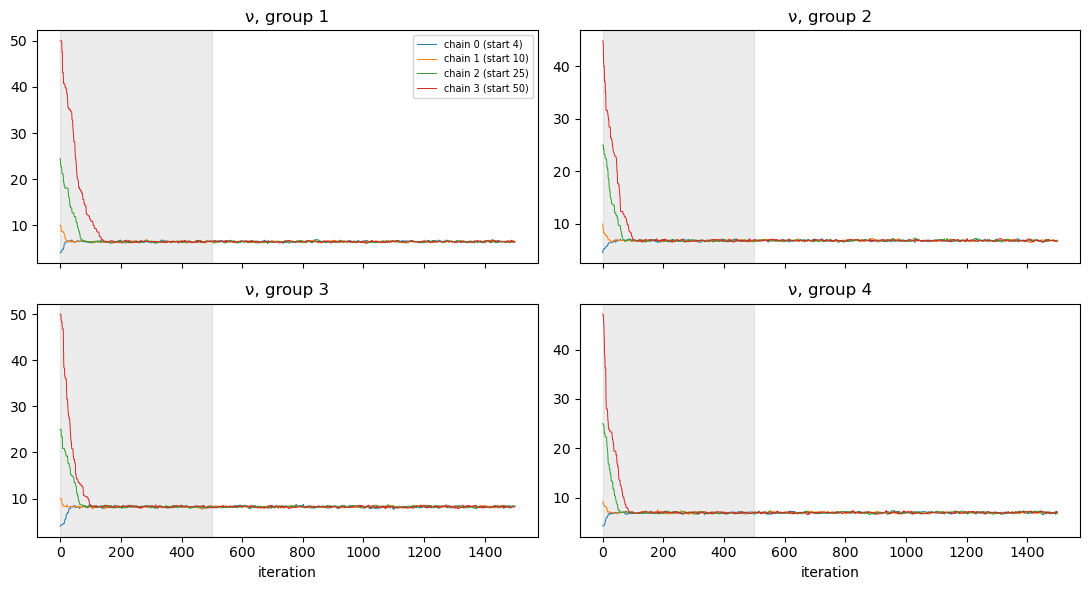

In [61]:
# Trace of \nu
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for g, ax in enumerate(axes.flat):
    for c, T in enumerate(Ts):
        ax.plot(T["nu"][:, g], lw=0.7, label=f"chain {c} (start {[4, 10, 25, 50][c]})")
    ax.axvspan(0, 500, color="grey", alpha=0.15)          # burn-in
    ax.set_title(f"ν, group {g+1}")
axes[0, 0].legend(fontsize=7)
axes[1, 0].set_xlabel("iteration"); axes[1, 1].set_xlabel("iteration")
plt.tight_layout(); plt.show()

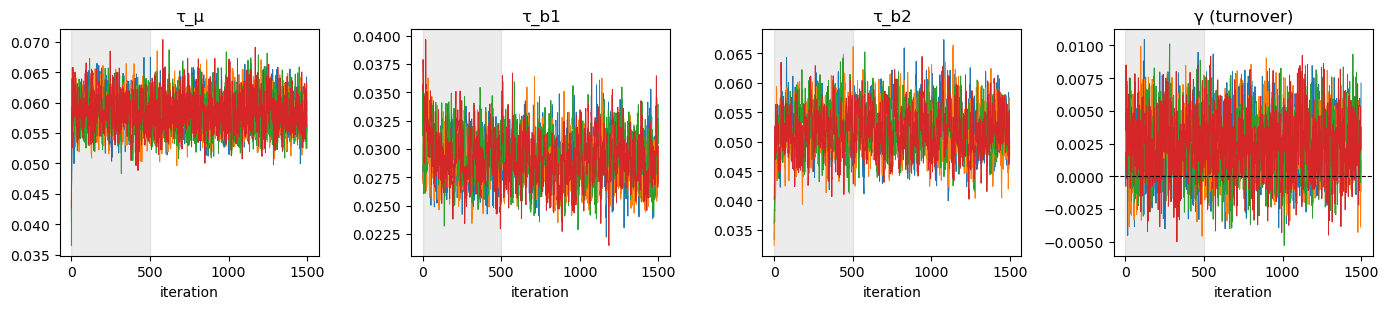

In [62]:
# Trace of \tau and \gamma
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharex=True)
for k, name in enumerate(["τ_μ", "τ_b1", "τ_b2"]):
    for T in Ts:
        axes[k].plot(T["tau"][:, k], lw=0.7)
    axes[k].set_title(name)
for T in Ts:
    axes[3].plot(T["gamma"], lw=0.7)
axes[3].axhline(0, color="k", lw=0.8, ls="--"); axes[3].set_title("γ (turnover)")
for ax in axes:
    ax.axvspan(0, 500, color="grey", alpha=0.15); ax.set_xlabel("iteration")
plt.tight_layout(); plt.show()

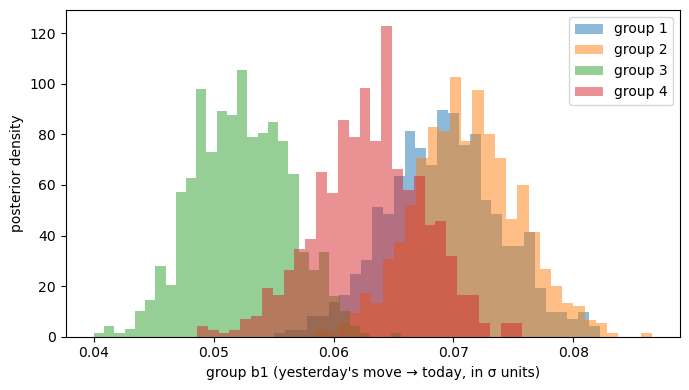

group 1: b1 = 0.069 ± 0.005
group 2: b1 = 0.071 ± 0.004
group 3: b1 = 0.052 ± 0.004
group 4: b1 = 0.063 ± 0.004


In [63]:
# Posterior of the group b1
b1g = D["theta_g"][:, :, 1]                     # pooled draws, shape (800, 4)
fig, ax = plt.subplots(figsize=(7, 4))
for g in range(4):
    ax.hist(b1g[:, g], bins=30, density=True, alpha=0.5, label=f"group {g+1}")
ax.set_xlabel("group b1 (yesterday's move → today, in σ units)"); ax.set_ylabel("posterior density")
ax.legend(); plt.tight_layout(); plt.show()

for g in range(4):
    print(f"group {g+1}: b1 = {b1g[:, g].mean():.3f} ± {b1g[:, g].std():.3f}")
others = np.delete(b1g, 2, axis=1).mean(1)

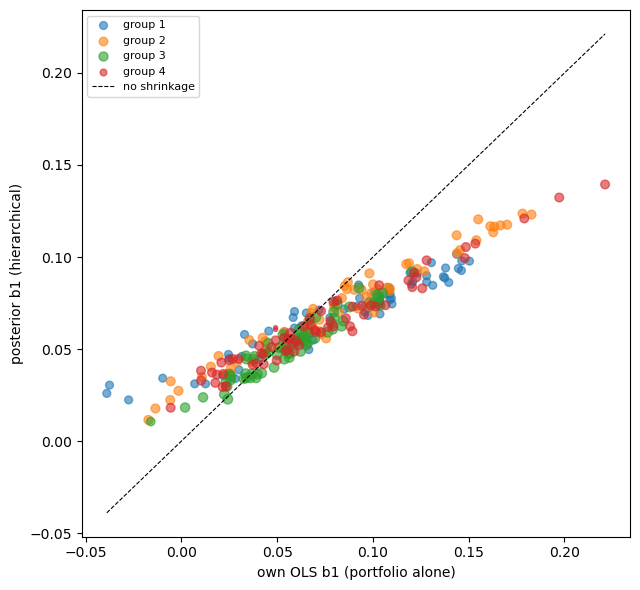

In [64]:
# Each portfolio's estimate vs the model 
own_b1 = np.array([np.linalg.lstsq(Z[S0["p"] == i], y[S0["p"] == i], rcond=None)[0][1]
                   for i in range(S0["A"])])
post_b1 = D["th_p"][:, :, 1].mean(0)

fig, ax = plt.subplots(figsize=(6.5, 6))
for g in range(4):
    m = S0["g_of_p"] == g
    ax.scatter(own_b1[m], post_b1[m], s=8 + S0["n_p"][m] / 60, alpha=0.6, label=f"group {g+1}")
lim = [min(own_b1.min(), post_b1.min()), max(own_b1.max(), post_b1.max())]
ax.plot(lim, lim, "k--", lw=0.8, label="no shrinkage")
ax.set_xlabel("own OLS b1 (portfolio alone)"); ax.set_ylabel("posterior b1 (hierarchical)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

All looks good honestly. The chains converge, $\hat{R}$ converges and the last plot is gold. We see that small points (portfolios with few rows) are pulled almost flat against their group value whilst large dots (portfolios with more rows) sit closer to the digaonal. Additionally, the diagonal crosses the cloud at about $0.06 -- 0.07$, i.e., where the group centers are. Below that, the model raises the estimate; above it, the model lowers it, with the pull always being towards the group. *To wit, we see that the model keeps the ranking of portfolios but discounts each one's own evidence by about half, which is what a cross-sectional spread of $\tau \approx 0.03$ against a per-portfolio standard error of about $0.025$ should roughly imply.


We can move on to predict things. How well do we do exactly? 

In [65]:
def predict_proba(D, X_new, Z_new, S):
    p = X_new["ALLOCATION"].map(S["alloc_index"])
    known = p.notna().to_numpy()
    p = p.fillna(0).astype(int).to_numpy()
    g = X_new["GROUP"].astype(int).to_numpy() - 1
    out = np.zeros(len(X_new))
    for th_p, th_g, sig, nu in zip(D["th_p"], D["theta_g"], D["sigma"], D["nu"]):
        th = np.where(known[:, None], th_p[p], th_g[g])            # unseen portfolio -> group values
        s  = np.where(known, sig[p], np.median(sig))
        out += stats.t.cdf((Z_new * th).sum(1) / s, nu[g])
    return out / len(D["nu"])

P_tr = predict_proba(D, X_train, Z, S0)
P_te = predict_proba(D, X_test, Zt, S0)

print("in-sample accuracy:", np.mean((P_tr > 0.5) == (X_train["target"] > 0)).round(4))
print("test rows predicted up:", np.mean(P_te > 0.5).round(3))
print("test portfolios unseen in training:", (~X_test["ALLOCATION"].isin(S0["alloc_index"])).sum(), "rows")
print("P quantiles (test):", np.quantile(P_te, [0.01, 0.25, 0.5, 0.75, 0.99]).round(3))

# calibration, as in within each bin of P, how often did the target actually go up?
cal = pd.DataFrame({"P": P_tr, "up": X_train["target"] > 0})
cal["bin"] = pd.qcut(cal["P"], 10)
print(cal.groupby("bin", observed=True)["up"].agg(["mean", "size"]).round(3))

in-sample accuracy: 0.5291
test rows predicted up: 0.557
test portfolios unseen in training: 0 rows
P quantiles (test): [0.415 0.484 0.505 0.526 0.605]
                 mean   size
bin                         
(0.255, 0.462]  0.439  52708
(0.462, 0.478]  0.467  52707
(0.478, 0.489]  0.487  52707
(0.489, 0.497]  0.497  52707
(0.497, 0.505]  0.505  52708
(0.505, 0.513]  0.509  52707
(0.513, 0.522]  0.520  52707
(0.522, 0.533]  0.527  52707
(0.533, 0.55]   0.542  52707
(0.55, 0.786]   0.579  52708


Above we just ran a quick check. We have somme good news as calibration seems on point. But we must run a proper K-fold validation on the stretches we built. We did not go trhough all of that to cheat at the last bit of course.

In [66]:
oof_hbm = np.full(len(X_train), np.nan)
oof_ols = np.full(len(X_train), np.nan)
oof_x1  = np.full(len(X_train), np.nan)

for f, (tr, va) in enumerate(GroupKFold(n_splits=5).split(X_train, groups=X_train["PIECE"])):
    Xtr, Xva = X_train.iloc[tr], X_train.iloc[va]
    vf = Xtr[RET].std(axis=1).quantile(0.01)                 # floor from the training part only
    Ztr, ytr, _ = make_xy(Xtr, vf)
    Zva, yva, _ = make_xy(Xva, vf)
    S = setup(Xtr, Ztr)
    Df, _ = fit_hbm(ytr, Ztr, S, n_iter=800, burn=300, thin=5, seed=f, verbose=False)
    oof_hbm[va] = predict_proba(Df, Xva, Zva, S)
    oof_ols[va] = Zva @ np.linalg.lstsq(Ztr, ytr, rcond=None)[0]
    oof_x1[va]  = Zva[:, 1]
    print(f"fold {f}: {Xva['TS'].nunique()} dates | HBM acc {np.mean((oof_hbm[va] > 0.5) == (yva > 0)):.4f}")

up = (X_train["target"] > 0).to_numpy()
preds = {"always up":  np.ones(len(up), bool),
         "sign(x1)":   oof_x1 >= 0,
         "pooled OLS": oof_ols > 0,
         "HBM":        oof_hbm > 0.5}

hits = {k: pd.Series(v == up, index=X_train.index).groupby(X_train["TS"]).mean() for k, v in preds.items()}
for k, h in hits.items():
    print(f"{k:11s}: {np.mean(preds[k] == up):.4f}   (per-date SE {h.std() / np.sqrt(len(h)):.4f})")

for ref in ["always up", "sign(x1)", "pooled OLS"]:
    d = hits["HBM"] - hits[ref]                                   # paired, per date
    print(f"HBM - {ref:10s}: {d.mean()*100:+.2f} pts  (z = {d.mean() / (d.std() / np.sqrt(len(d))):.1f})")

fold 0: 461 dates | HBM acc 0.5186
fold 1: 464 dates | HBM acc 0.5208
fold 2: 520 dates | HBM acc 0.5265
fold 3: 544 dates | HBM acc 0.5258
fold 4: 533 dates | HBM acc 0.5271
always up  : 0.5072   (per-date SE 0.0019)
sign(x1)   : 0.5189   (per-date SE 0.0018)
pooled OLS : 0.5198   (per-date SE 0.0018)
HBM        : 0.5238   (per-date SE 0.0017)
HBM - always up : +2.21 pts  (z = 9.6)
HBM - sign(x1)  : +0.59 pts  (z = 4.7)
HBM - pooled OLS: +0.47 pts  (z = 4.2)


We have done some solid work it seem. We find a $9\sigma$ edge over the most vanilla model and with respect to the pooled OLS we are still above $4\sigma$ (this looks like the value of the hierarchy we have implemented). 

However, the per-date standard error deals with portfolios being correlated on the same day. It does not deal with neighbouring days being correlated. Thus, as predictions on consecutive days share 19 of their 20 input days their hits aren't independent. The $z$ value might therefore be inflated. Let us check this via some nice bootstrap.

In [67]:
diff = (hits["HBM"] - hits["pooled OLS"])
piece_of_date = X_train.groupby("TS")["PIECE"].first()
by_piece = pd.DataFrame({"d": diff, "piece": piece_of_date.reindex(diff.index)}).groupby("piece")["d"].agg(["sum", "size"])

rng = np.random.default_rng(0)
boot = []
for _ in range(5000):
    idx = rng.integers(0, len(by_piece), len(by_piece))          # resample stretches with replacement
    s = by_piece.iloc[idx]
    boot.append(s["sum"].sum() / s["size"].sum())
boot = np.array(boot)
print(f"HBM - pooled OLS: {diff.mean()*100:+.2f} pts, block-bootstrap SE {boot.std()*100:.2f} pts, "
      f"z = {diff.mean()/boot.std():.1f}")

HBM - pooled OLS: +0.47 pts, block-bootstrap SE 0.13 pts, z = 3.7


So, althogh the serial correlation was doing some work, we still have some strogn evidence for an edge. Not bad. Like, honestly, we are gaining edge here. 

And yet, we still have to use the signed volume information we encountered at the very beginning.

### Model inputs: returns and signed volume

In addition to the inputs designed for the HBM, we now consider the possible extra information carried over 
by the signed volume. 

In particular, we are going to focus (give our initial plots) to the (SIGNED_VOLUME_2,...,SIGNED_VOLUME_5) features, leaving out SIGNED_VOLUME_1 as it is often missing in both test and train set. In particular, we introduce first

$$
v_i = \tfrac14\big(\text{SV}_2 + \text{SV}_3 + \text{SV}_4 + \text{SV}_5\big),
$$

namely, for each row we average the signed volume over the four days before RET_1's day. This is then standardised with constants fitted on the training rows only (median $m$, scale $s_v = \text{IQR}/1.349$). Finally, we are also going to have to handle the fat-tails somewhat to avoid any single day dominating the Bayesian analysis, but not a real problem. We just apply a nice $\text{arcsinh}$ transform. To wit, we use as new feature:

$$
x_{3,i} = \operatorname{arcsinh}\!\left(\frac{v_i - m}{s_v}\right).
$$

We note that, unlike the returns, $x_3$ is **not** divided by the window vol $s$ since volume is already dimensionless. A missing value becomes $x_3 = 0$, i.e., a "typical volume".

In [68]:
VOL25 = [f"SIGNED_VOLUME_{i}" for i in range(2, 6)]

def vol_stats(X):                                   # centre and scale, from training rows only
    v = X[VOL25].mean(axis=1)
    q25, q50, q75 = v.quantile([0.25, 0.5, 0.75])
    return q50, (q75 - q25) / 1.349

def make_xy(X, vol_floor, vstat=None, vol_transform="arcsinh"):
    s  = X[RET].std(axis=1).clip(lower=vol_floor)
    x1 = (X["RET_1"] / s).clip(-4, 4).fillna(0)
    x2 = (X[["RET_2", "RET_3", "RET_4", "RET_5"]].mean(axis=1) / s).clip(-4, 4).fillna(0)
    cols = [np.ones(len(X)), x1, x2]
    if vstat is not None:
        z = (X[VOL25].mean(axis=1) - vstat[0]) / vstat[1]
        x3 = np.arcsinh(z) if vol_transform == "arcsinh" else z.clip(-4, 4)
        cols.append(x3.fillna(0))
    Z = np.column_stack(cols)
    y = (X["target"] / s).to_numpy() if "target" in X else None
    return Z, y, s.to_numpy()

vstat = vol_stats(X_train)
Zv, y, s  = make_xy(X_train, vol_floor, vstat)
Zvt, _, _ = make_xy(X_test,  vol_floor, vstat)

# --- checks ---
x3 = Zv[:, 3]
print("vstat (centre, scale):", np.round(vstat, 3))
print("x3 range train: %.2f to %.2f | test: %.2f to %.2f" % (x3.min(), x3.max(), Zvt[:, 3].min(), Zvt[:, 3].max()))
print("x3 mean %.3f  std %.3f  skew %.2f" % (x3.mean(), x3.std(), pd.Series(x3).skew()))
print("corr(x3, x1) = %.3f | corr(x3, x2) = %.3f" % (np.corrcoef(x3, Zv[:, 1])[0, 1], np.corrcoef(x3, Zv[:, 2])[0, 1]))
beta4 = np.linalg.lstsq(Zv, y, rcond=None)[0]
print("pooled OLS [drift, b1, b2, b3]:", beta4.round(4))
print("in-sample accuracy, 3 inputs: %.4f | 4 inputs: %.4f" %
      (np.mean(np.sign(Zv[:, :3] @ beta) == np.sign(y)), np.mean(np.sign(Zv @ beta4) == np.sign(y))))

vstat (centre, scale): [0.666 1.352]
x3 range train: -3.83 to 3.55 | test: -3.01 to 2.69
x3 mean -0.221  std 0.726  skew -0.19
corr(x3, x1) = -0.006 | corr(x3, x2) = 0.021
pooled OLS [drift, b1, b2, b3]: [ 0.0082  0.0772 -0.0157 -0.0108]
in-sample accuracy, 3 inputs: 0.5198 | 4 inputs: 0.5202


OK. So the good news are that (i) the volume input $x_3$ is well behaved (ii) it is essentially orthogonal to the return inputs ($\mathrm{corr}(x_3,x_1)=-0.006$, $\mathrm{corr}(x_3,x_2)=0.021$), and (iii) its pooled coefficient is negative ($b_3=-0.0108$).

However, the effect is really  modest, with a $1\sigma$ move in $x_3$ only changing the forecast by about $0.008\sigma$. Adding it improves in-sample accuracy only slightly, from $0.5198$ to $0.5202$. Now, we can hope that the hierarchical might capture differences here averaged away.

### The volume-incorporeted model (VHBM)

We now add a new input per row:

- the $b_3$ coefficient, namely the change in the expected next-day return (in units of the window vol) per unit of $x_3$.

Therefore, we are effectively modelling our data as (in expanded form) 

$$
y_i = \mu_p + b_{1,p}\,x_{1,i} + b_{2,p}\,x_{2,i} + b_{3,p}\,x_{3,i} + \sigma_p\,\epsilon_i, \qquad \epsilon_i \sim t_{\nu_g}\, .
$$

Here, $b_3 < 0$ would signal the *reversal of price pressure* (i.e., what our lead–lag plots suggested for groups 1, 3, 4), whilst $b_3 > 0$ implies that the flow continues. Morevoer, note that technically $b_3$ is the effect of volume given the recent returns. It is not the raw correlation we plotted before.

**In the hierarchy nothing changes**. Indeed, $\theta$ just gains a fourth component so that $\theta_p = (\mu_p, b_{1,p}, b_{2,p}, b_{3,p})$ and we have that each portfolio gets its own $b_{3,p}, pulled towards its group's $b_{3,g}$. At the same time $\tau_{b_3}$ (which is estimated) says how much portfolios within a group differ in their response to flow, and $\omega_{b_3}$ indicates how much the groups differ. Priors are as before.

We do not remove the turnover yet to have a clear-cut comparison with HBM. Even in the next-to-final step we will take we shall keep it for comparison. Then we remove it at the very end if it plays no role at all as it seems.

In [69]:
Sv = setup(X_train, Zv)
runs_v = [fit_hbm(y, Zv, Sv, seed=s, nu_start=v, verbose=False) for s, v in enumerate([4, 10, 25, 50])]
Dvs = [r[0] for r in runs_v]; Tvs = [r[1] for r in runs_v]
Dv  = {k: np.concatenate([d[k] for d in Dvs]) for k in Dvs[0]}

# convergence of the new quantities
print("R-hat tau_b3:", round(rhat(np.array([d["tau"][:, 3] for d in Dvs])), 3))
for g in range(4):
    print(f"R-hat b3, group {g+1}:", round(rhat(np.array([d["theta_g"][:, g, 3] for d in Dvs])), 3))

# summary
b3g = Dv["theta_g"][:, :, 3]
print("\nnu by group:       ", Dv["nu"].mean(0).round(1))
print("tau (mu,b1,b2,b3): ", Dv["tau"].mean(0).round(3))
print("group b1:          ", Dv["theta_g"][:, :, 1].mean(0).round(3))
print("group b2:          ", Dv["theta_g"][:, :, 2].mean(0).round(3))
for g in range(4):
    print(f"group {g+1} b3 = {b3g[:, g].mean():+.4f} ± {b3g[:, g].std():.4f}   P(b3 < 0) = {np.mean(b3g[:, g] < 0):.3f}")
post_b3 = Dv["th_p"][:, :, 3].mean(0)
print("portfolios with P(b3_p < 0) > 0.9:", np.mean((Dv["th_p"][:, :, 3] < 0).mean(0) > 0.9).round(3))

R-hat tau_b3: 1.016
R-hat b3, group 1: 1.009
R-hat b3, group 2: 1.004
R-hat b3, group 3: 1.012
R-hat b3, group 4: 1.002

nu by group:        [6.4 6.8 8.2 6.9]
tau (mu,b1,b2,b3):  [0.057 0.029 0.052 0.015]
group b1:           [0.069 0.071 0.052 0.063]
group b2:           [-0.008 -0.035 -0.074 -0.011]
group 1 b3 = -0.0211 ± 0.0052   P(b3 < 0) = 1.000
group 2 b3 = -0.0000 ± 0.0046   P(b3 < 0) = 0.501
group 3 b3 = -0.0066 ± 0.0041   P(b3 < 0) = 0.950
group 4 b3 = -0.0213 ± 0.0048   P(b3 < 0) = 1.000
portfolios with P(b3_p < 0) > 0.9: 0.338


Converged, and we see a big spread in the groups $b_3$ which the vanilla OLS averaged away. This is damn good news. Note also that it matches almost exactly the lag-plots predictions. It did not have to a priori. Also looking at $\tau_{b_3}$ we see that the data clearly moved it from the priors. Another good news.

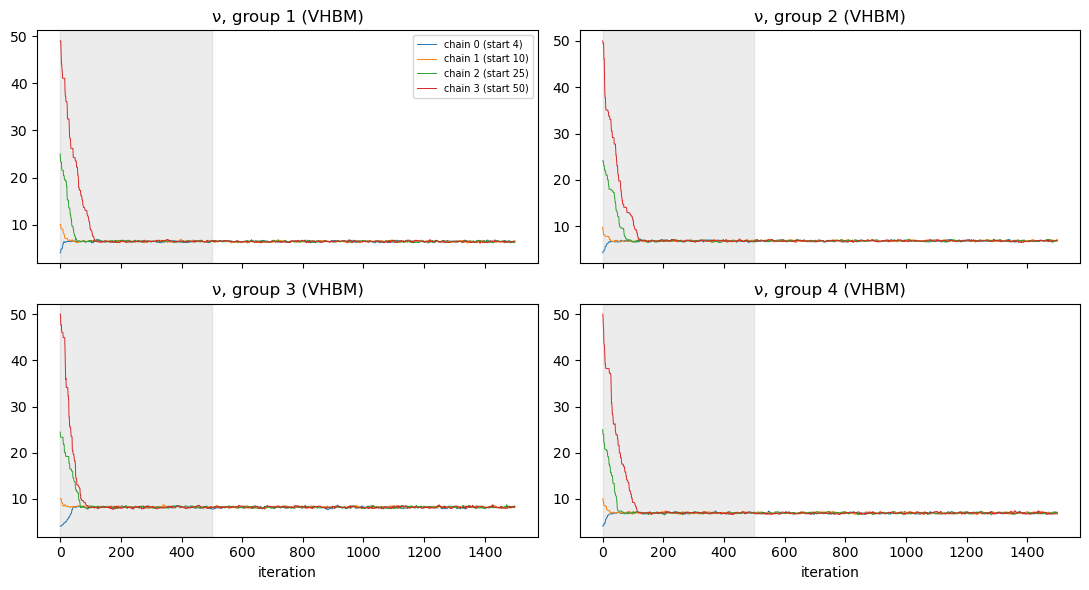

In [70]:
# still good to check I mean...
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for g, ax in enumerate(axes.flat):
    for c, T in enumerate(Tvs):
        ax.plot(T["nu"][:, g], lw=0.7, label=f"chain {c} (start {[4, 10, 25, 50][c]})")
    ax.axvspan(0, 500, color="grey", alpha=0.15)
    ax.set_title(f"ν, group {g+1} (VHBM)")
axes[0, 0].legend(fontsize=7)
axes[1, 0].set_xlabel("iteration"); axes[1, 1].set_xlabel("iteration")
plt.tight_layout(); plt.show()

Yup, it converges.

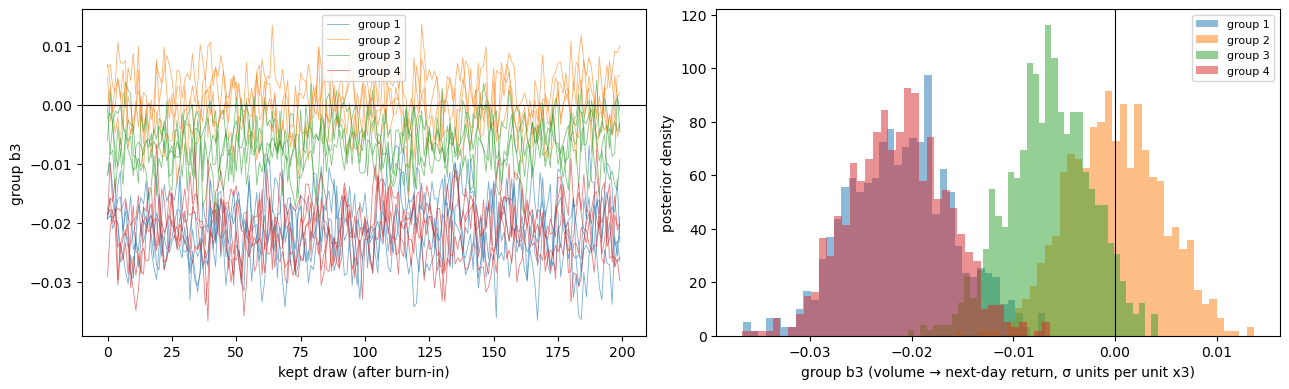

group 1: b3 = -0.0211 ± 0.0052 | P(b3 < 0) = 1.000
group 2: b3 = -0.0000 ± 0.0046 | P(b3 < 0) = 0.501
group 3: b3 = -0.0066 ± 0.0041 | P(b3 < 0) = 0.950
group 4: b3 = -0.0213 ± 0.0048 | P(b3 < 0) = 1.000


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for g in range(4):
    for c, d in enumerate(Dvs):
        axes[0].plot(d["theta_g"][:, g, 3], lw=0.6, color=f"C{g}", alpha=0.6,
                     label=f"group {g+1}" if c == 0 else None)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("kept draw (after burn-in)"); axes[0].set_ylabel("group b3")
axes[0].legend(fontsize=8); 

b3g = Dv["theta_g"][:, :, 3]
for g in range(4):
    axes[1].hist(b3g[:, g], bins=40, density=True, alpha=0.5, color=f"C{g}", label=f"group {g+1}")
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("group b3 (volume → next-day return, σ units per unit x3)"); axes[1].set_ylabel("posterior density")
axes[1].legend(fontsize=8); 
plt.tight_layout(); plt.show()

for g in range(4):
    print(f"group {g+1}: b3 = {b3g[:, g].mean():+.4f} ± {b3g[:, g].std():.4f} | P(b3 < 0) = {np.mean(b3g[:, g] < 0):.3f}")

Looking sweet here as well. The posterior clearly shows the differences between groups.

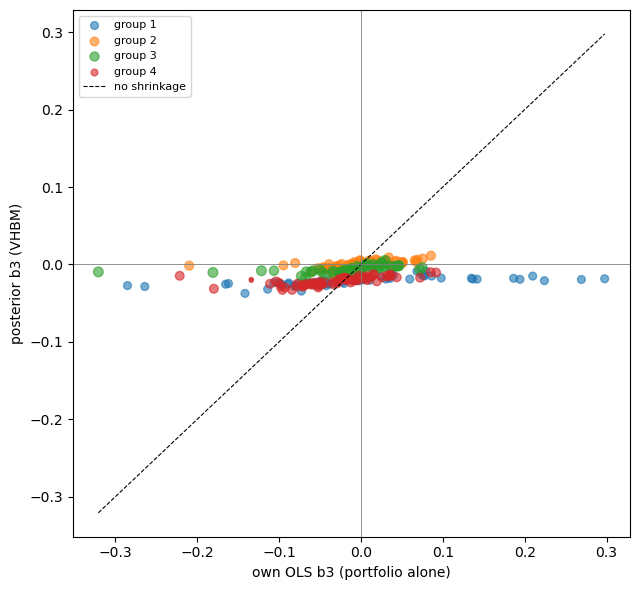

In [72]:
own_b3 = np.array([np.linalg.lstsq(Zv[Sv["p"] == i], y[Sv["p"] == i], rcond=None)[0][3]
                   for i in range(Sv["A"])])
post_b3 = Dv["th_p"][:, :, 3].mean(0)

fig, ax = plt.subplots(figsize=(6.5, 6))
for g in range(4):
    m = Sv["g_of_p"] == g
    ax.scatter(own_b3[m], post_b3[m], s=8 + Sv["n_p"][m] / 60, alpha=0.6, label=f"group {g+1}")
lim = [min(own_b3.min(), post_b3.min()), max(own_b3.max(), post_b3.max())]
ax.plot(lim, lim, "k--", lw=0.8, label="no shrinkage")
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel("own OLS b3 (portfolio alone)"); ax.set_ylabel("posterior b3 (VHBM)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Well, the hierarchy is doing some real work. Each portfolio's $b_3$ is clearly shrinked towards the one of the group!

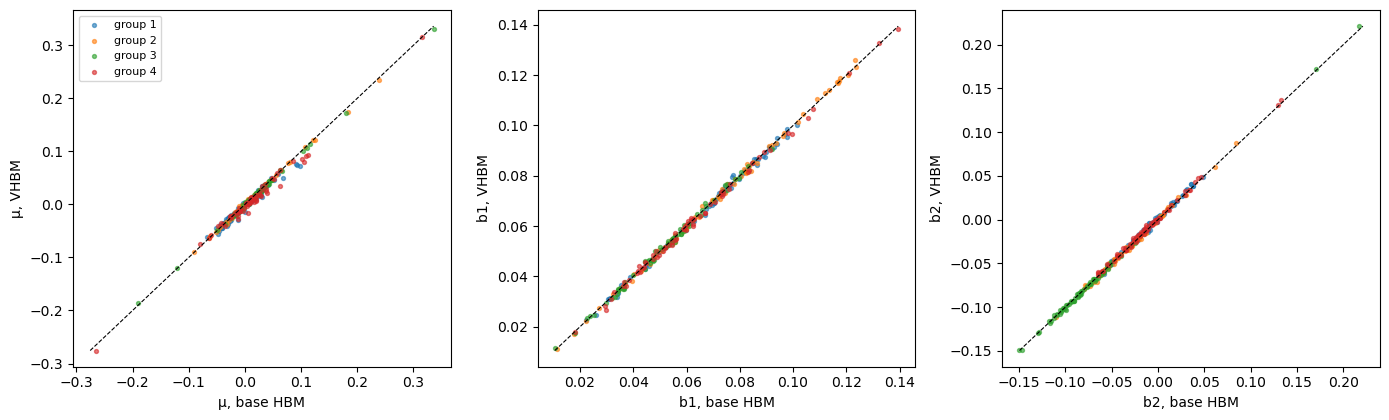

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for k, name in enumerate(["μ", "b1", "b2"]):
    a, b = D["th_p"][:, :, k].mean(0), Dv["th_p"][:, :, k].mean(0)
    for g in range(4):
        m = Sv["g_of_p"] == g
        axes[k].scatter(a[m], b[m], s=8, alpha=0.6, label=f"group {g+1}")
    lim = [min(a.min(), b.min()), max(a.max(), b.max())]
    axes[k].plot(lim, lim, "k--", lw=0.8)
    axes[k].set_xlabel(f"{name}, base HBM"); axes[k].set_ylabel(f"{name}, VHBM"); 
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

Perfect. The parameters present before essentially did not shift. We added proper information orthogonal to what we had before.

### VHBM testing

In [76]:
oof_vhbm = np.full(len(X_train), np.nan)
b3_folds = []
for f, (tr, va) in enumerate(GroupKFold(n_splits=5).split(X_train, groups=X_train["PIECE"])):
    Xtr, Xva = X_train.iloc[tr], X_train.iloc[va]
    vf, vs = Xtr[RET].std(axis=1).quantile(0.01), vol_stats(Xtr)          # both from the training part only
    Ztr, ytr, _ = make_xy(Xtr, vf, vs)
    Zva, yva, _ = make_xy(Xva, vf, vs)
    S = setup(Xtr, Ztr)
    Df, _ = fit_hbm(ytr, Ztr, S, n_iter=800, burn=300, thin=5, seed=f, verbose=False)
    oof_vhbm[va] = predict_proba(Df, Xva, Zva, S)
    b3_folds.append(Df["theta_g"][:, :, 3].mean(0))
    print(f"fold {f}: VHBM {np.mean((oof_vhbm[va] > 0.5) == (yva > 0)):.4f} | "
          f"HBM {np.mean((oof_hbm[va] > 0.5) == (yva > 0)):.4f} | b3 by group {np.round(b3_folds[-1], 3)}")

up = (X_train["target"] > 0).to_numpy()
hit_v = pd.Series((oof_vhbm > 0.5) == up, index=X_train.index)
hit_h = pd.Series((oof_hbm  > 0.5) == up, index=X_train.index)

fold 0: VHBM 0.5192 | HBM 0.5186 | b3 by group [-0.027 -0.006 -0.006 -0.024]
fold 1: VHBM 0.5213 | HBM 0.5208 | b3 by group [-0.024  0.008 -0.004 -0.011]
fold 2: VHBM 0.5254 | HBM 0.5265 | b3 by group [-0.018 -0.01  -0.011 -0.019]
fold 3: VHBM 0.5247 | HBM 0.5258 | b3 by group [-0.022  0.003 -0.009 -0.027]
fold 4: VHBM 0.5284 | HBM 0.5271 | b3 by group [-0.016  0.007 -0.005 -0.025]


In [77]:
# overall, paired per date
d = hit_v.groupby(X_train["TS"]).mean() - hit_h.groupby(X_train["TS"]).mean()
print(f"\nVHBM {hit_v.mean():.4f} | HBM {hit_h.mean():.4f} | difference {d.mean()*100:+.2f} pts")
print(f"per-date z = {d.mean() / (d.std() / np.sqrt(len(d))):.1f} | calls changed: {np.mean((oof_vhbm > 0.5) != (oof_hbm > 0.5)):.3f}")


VHBM 0.5238 | HBM 0.5238 | difference -0.00 pts
per-date z = -0.1 | calls changed: 0.041


In [78]:
# block bootstrap over stretches (conservative) 
piece_of_date = X_train.groupby("TS")["PIECE"].first()
bp = pd.DataFrame({"d": d, "piece": piece_of_date.reindex(d.index)}).groupby("piece")["d"].agg(["sum", "size"])
rng = np.random.default_rng(0)
boot = np.array([bp.iloc[i]["sum"].sum() / bp.iloc[i]["size"].sum()
                 for i in (rng.integers(0, len(bp), len(bp)) for _ in range(5000))])
print(f"block-bootstrap SE {boot.std()*100:.2f} pts, z = {d.mean() / boot.std():.1f}")

block-bootstrap SE 0.04 pts, z = -0.1


In [79]:
# by group
print("\nby group:")
for g in sorted(X_train["GROUP"].unique()):
    m = (X_train["GROUP"] == g).to_numpy()
    dg = hit_v[m].groupby(X_train["TS"][m]).mean() - hit_h[m].groupby(X_train["TS"][m]).mean()
    print(f"  group {g}: VHBM {hit_v[m].mean():.4f} | HBM {hit_h[m].mean():.4f} | "
          f"{dg.mean()*100:+.2f} pts (per-date z = {dg.mean() / (dg.std() / np.sqrt(len(dg))):.1f})")


by group:
  group 1: VHBM 0.5214 | HBM 0.5219 | -0.05 pts (per-date z = -0.6)
  group 2: VHBM 0.5266 | HBM 0.5267 | -0.02 pts (per-date z = -0.4)
  group 3: VHBM 0.5237 | HBM 0.5240 | -0.02 pts (per-date z = -0.6)
  group 4: VHBM 0.5228 | HBM 0.5218 | +0.10 pts (per-date z = 1.0)


And so we were optimistic and wrong. Adding the signed_volume (at least as we did!) does not better accuracy! 
It was a good try, and it is always important to check wheteher having used the whole information matters or not. Here, it did not. I mean, after all, a significant coefficient is not the same as a better prediction.

Mind you, I do not think this is not because volume is totally uninformative. In-sample it shows a clear, interpretable effect. But the effect is small, about a fifth of the lag-1 effect, so it shifts forecasts by too little to flip sign calls, and accuracy only rewards flips.

So the volume term is dropped and the model stays at HBM. 

BUT, we are not done...

### Time-varying HBM model (THBM)

So, we built a nice HBM. Tried a VHBM and discrded it. What do we want to try next? Well, one more thing worth it would be to allow for **time-dependent parameters** in the HBM.

Why would we possibly think to look into that? The point is that the HBM model assumes that each portfolio's behaviour is fixed. To wit, we calcualte parameters over some years of data and we use this "average" description on the test set. But, if there is an actual time drift in how the model behaves this might be a problem. 

However, it looks like there is actual evidence that such a non-stationary behaviour is present. Indeed (i)  the realised lag-1 slope varies from stretch to stretch (more than noise seems to allow), (ii) the lag-1 autocorrelation inside the test windows is about half the training value.

So, maybe. A time-varying hierarchy might actually be really good for our aim. 

In particular, the THBM is build by adding a period-specific deviation to each portfolio with shrinking towards its long-run value, i.e., we model

$$
y_i = Z_i\cdot\big(\theta_p + \delta_{p,t(i)}\big) + \sigma_p\,\epsilon_i, \qquad
\delta_{p,t} \sim \mathcal{N}\!\big(0,\ \mathrm{diag}[\eta^2]\big)\,,
$$

where $t(i)$ is the period of row $i$. Here, we use one period per training stretch, plus one TEST period built from something we can call "pseudo-rows". What are these pesudo-rows? Glad someone asked. 

Well, note that a test row contains all the last 20 daily returns but no target. However, if we shift the window back by k days, then the day RET_k becomes a "target" whose inputs (RET_{k+1}, RET_{k+2}, …) are all in the same window. Therfore, each shifted copy is a complete (inputs → next-day outcome) example built only from the test features. We would be just using a recent history a trader would look at. This way we build pseudo-rows.


Everything else in the model (groups, $\tau$, $\omega$, $\nu_g$, the Student-t tails) is unchanged.

We therefore want to introduce the $\eta$ parameter (estimated), representing the **typical drift of a portfolio's coefficients from one period to the next**. To wit, it plays the same role in time that $\tau$ plays across portfolios (and it has the same exact prior!). Thus, we see that if the behaviour is stable we will recover $\eta \to 0$ and every $\delta \to 0$ leading to HBM exactly. On the other hand, if the behaviour drifts, then test prediction uses $\theta_p + \delta_{p,\mathrm{TEST}}$. That is the long-run value corrected by what the test windows show, weighted by how informative they are. 

Let's see if this extension now matters or not. 

In [80]:
# We of course start by building speudo-rows

def pseudo_rows(X, kmax=15):
    base = X[["TS", "ALLOCATION", "GROUP", "MEDIAN_DAILY_TURNOVER"]]
    out = []
    for k in range(1, kmax + 1):
        P = base.copy()
        P["TS"] = P["TS"].astype(str) + f"_k{k}"            # pseudo-dates never collide with real ones
        P["K"] = k
        for j in range(1, 21):
            P[f"RET_{j}"] = X[f"RET_{j + k}"].to_numpy() if j + k <= 20 else np.nan
        P["target"] = X[f"RET_{k}"].to_numpy()
        out.append(P)
    P = pd.concat(out, ignore_index=True)
    keep = P[[f"RET_{j}" for j in range(1, 6)]].notna().all(axis=1) & P["target"].notna()
    return P[keep].reset_index(drop=True)

Ptest = pseudo_rows(X_test)
print("test windows:", len(X_test), "| pseudo-rows:", len(Ptest), "| per window:", round(len(Ptest) / len(X_test), 2))

test windows: 31870 | pseudo-rows: 476486 | per window: 14.95


Our previous discussion of THBM is based on the assumption that rows and pseudo-rows give back the same "reality" when looking at the same stretch of data. But we have to check, of course.

In [85]:
# We check that things actually do work. As first check, do we reproduce what is already there?
X_train["POS"] = X_train.groupby("PIECE")["POS"].transform("max") - X_train["POS"]   # make POS run forward
X_train.to_pickle(os.path.join("./", "train_sorted.pkl"))
Ptr = pseudo_rows(X_train, kmax=1)
Ptr["TS0"] = Ptr["TS"].str.replace("_k1", "", regex=False)
key = X_train[["TS", "ALLOCATION", "PIECE", "POS"]]
a = Ptr.merge(key, left_on=["TS0", "ALLOCATION"], right_on=["TS", "ALLOCATION"])[["ALLOCATION", "PIECE", "POS", "target"]]
b = X_train[["ALLOCATION", "PIECE", "POS", "target"]].copy(); b["POS"] += 1           # the previous date, shifted onto t
m = a.merge(b, on=["ALLOCATION", "PIECE", "POS"], suffixes=("_pseudo", "_real"))
print("matched pairs:", len(m), "| corr:", m["target_pseudo"].corr(m["target_real"]).round(3),
      "| same sign:", (np.sign(m["target_pseudo"]) == np.sign(m["target_real"])).mean().round(3))

matched pairs: 506353 | corr: -0.0 | same sign: 0.5


OK, good correlation and sign matching. Seems reasonable.

In [ ]:
# Check 2, does the pooled OLS obtained with psudo-rows and rows differ much?
Ptr15 = pseudo_rows(X_train)
Zp, yp, _  = make_xy(Ptr15, vol_floor)
Zpt, ypt, _ = make_xy(Ptest, vol_floor)
for name, (A_, b_) in {"real train rows": (Z, y), "train pseudo-rows": (Zp, yp), "test pseudo-rows": (Zpt, ypt)}.items():
    beta_ = np.linalg.lstsq(A_, b_, rcond=None)[0]
    print(f"{name:18s}: [drift, b1, b2] = {beta_.round(4)}   (n = {len(b_):,})")

real train rows   : [drift, b1, b2] = [ 0.0106  0.0772 -0.016 ]   (n = 527,073)
train pseudo-rows : [drift, b1, b2] = [ 0.0119  0.046  -0.0287]   (n = 7,905,833)
test pseudo-rows  : [drift, b1, b2] = [0.0156 0.0248 0.0226]   (n = 476,486)


DANGER LIGHT FLARING! We see that the pseudo-rows are not equivalent to the real rows. We see that on training data the pseudo-rows fitted $b_1$ is $40\%$ smaller than the one predicted with real rows, and $b_2$ is also more negative. Moreover, something funky is going on with the test pesudo-rows (half of $b_1$, which could be a genuine signal, but suspiscious at the present time).

Such a difference would clearly distort our THBM fitting, making the model unusable. Now, to decide if a correction is even possible we should check whether the row vs pseudo-row distorsion comes from (i) the normalisation of the pseudo-rows via the standard deviation of the $20-k$ days which could shrink $b_1$ naturally as $k$ grows; or (ii) *the window returns may not be the realized returns*. Indeed, if e.g., each window is re-computed with the *current* weights of the portfolio then the within-window hisotry is a backcast and the lag structure is distorted. That would most likely sunk our THBM.

We can check if it is the first mechanism.

In [86]:
rows = []
for k in range(1, 16):
    m = (Ptr15["K"] == k).to_numpy()
    bk = np.linalg.lstsq(Zp[m], yp[m], rcond=None)[0]
    rows.append((k, m.sum(), *bk.round(4)))
print(pd.DataFrame(rows, columns=["k", "n", "drift", "b1", "b2"]).to_string(index=False))
print("real rows:            b1 = 0.0772, b2 = -0.0160")

 k      n  drift     b1      b2
 1 527073 0.0251 0.0613 -0.0143
 2 527073 0.0142 0.0491 -0.0204
 3 527073 0.0134 0.0463 -0.0263
 4 527073 0.0121 0.0449 -0.0304
 5 527071 0.0122 0.0452 -0.0285
 6 527069 0.0109 0.0464 -0.0322
 7 527067 0.0102 0.0460 -0.0318
 8 527064 0.0101 0.0459 -0.0300
 9 527060 0.0097 0.0461 -0.0293
10 527055 0.0093 0.0426 -0.0296
11 527047 0.0095 0.0441 -0.0290
12 527039 0.0093 0.0443 -0.0288
13 527031 0.0095 0.0453 -0.0294
14 527023 0.0106 0.0428 -0.0310
15 527015 0.0125 0.0410 -0.0328
real rows:            b1 = 0.0772, b2 = -0.0160


Nope, it is not the short-window effect. This could well exists, but it's at most a minor contributor. 

The bias must be structural. To wit, something about how a window's own history relates to the next realized day makes pseudo-rows and rows different. Maybe is backcast. Maybe not. Regardless, we are in a direct bind.

A possible way out which would make a THBM still a meaningful route could be to introduce a "pseudo-row" offset for each group $\kappa_{g,c(i)}$ next to the $\delta_{p,t(i)}$. We would have to estimate it of course. 

However, before committing to anyting we must check if such a correction actually makes sense, i.e., we must test that such a correction is stable. The best way is to check whether the gap between the real rows $b_1$ and the pseudo-rows $b_1$ (using pooled OLS) remains constant. If it varies a lot, the idea is no good.

So we test that, coupled to an homogeneity test on the $\bar{\chi}^2$ (if it works should be $\approx$ to the number of stretches - 1) and also verify whether the stretch itself correlates to the values of $b_1$.

Let us hope for the best.

In [87]:
from scipy.stats import chi2

piece_of_ts = X_train.groupby("TS")["PIECE"].first()
Ptr15["PIECE"] = Ptr15["TS"].str.rsplit("_k", n=1).str[0].map(piece_of_ts).to_numpy()

def ols_b(Zs, ys):
    beta = np.linalg.lstsq(Zs, ys, rcond=None)[0]
    s2 = np.var(ys - Zs @ beta)
    return beta, np.sqrt(np.diag(s2 * np.linalg.inv(Zs.T @ Zs)))

sizes = X_train.groupby("PIECE")["TS"].nunique()
pieces = sizes[sizes >= 40].index
real_piece, ps_piece, ps_k = X_train["PIECE"].to_numpy(), Ptr15["PIECE"].to_numpy(), Ptr15["K"].to_numpy()

rows = []
for pc in pieces:
    br, sr = ols_b(Z[real_piece == pc], y[real_piece == pc])
    out = {"piece": pc, "dates": sizes[pc], "b1_real": br[1], "b2_real": br[2]}
    for k in (1, 5):
        m = (ps_piece == pc) & (ps_k == k)
        bp, sp = ols_b(Zp[m], yp[m])
        for j, name in [(1, "b1"), (2, "b2")]:
            out[f"gap_{name}_k{k}"] = br[j] - bp[j]
            out[f"se_{name}_k{k}"] = np.sqrt(sr[j]**2 + sp[j]**2)
    rows.append(out)
G = pd.DataFrame(rows)

print(f"{len(G)} stretches with >= 40 dates\n")
for name in ["b1", "b2"]:
    for k in (1, 5):
        g, se = G[f"gap_{name}_k{k}"], G[f"se_{name}_k{k}"]
        w = 1 / se**2; mean = (w * g).sum() / w.sum()
        stat = (((g - mean) / se)**2).sum(); dof = len(g) - 1
        print(f"{name}, k={k}: mean gap {mean:+.4f} | sd across stretches {g.std():.4f} | median se {se.median():.4f} | "
              f"chi2 = {stat:.1f} on {dof} dof (p = {chi2.sf(stat, dof):.3f}) | corr(gap, real b1) = {g.corr(G['b1_real']):+.2f}")

23 stretches with >= 40 dates

b1, k=1: mean gap +0.0127 | sd across stretches 0.0183 | median se 0.0111 | chi2 = 40.2 on 22 dof (p = 0.010) | corr(gap, real b1) = +0.74
b1, k=5: mean gap +0.0278 | sd across stretches 0.0279 | median se 0.0113 | chi2 = 90.9 on 22 dof (p = 0.000) | corr(gap, real b1) = +0.63
b2, k=1: mean gap -0.0034 | sd across stretches 0.0198 | median se 0.0209 | chi2 = 14.4 on 22 dof (p = 0.888) | corr(gap, real b1) = +0.38
b2, k=5: mean gap +0.0127 | sd across stretches 0.0380 | median se 0.0212 | chi2 = 46.7 on 22 dof (p = 0.002) | corr(gap, real b1) = +0.34


Well that is just not good.

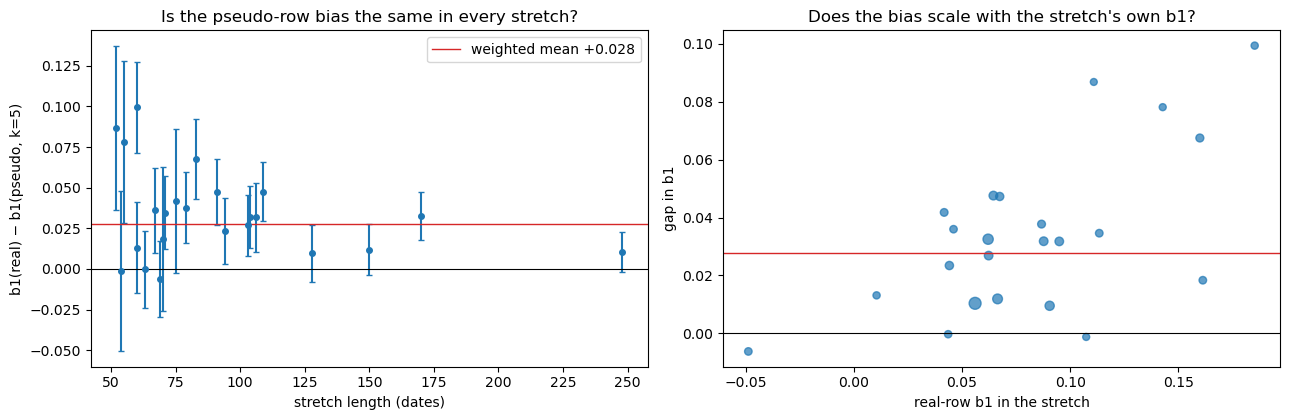

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
g, se = G["gap_b1_k5"], G["se_b1_k5"]
w = 1 / se**2; mean = (w * g).sum() / w.sum()
axes[0].errorbar(G["dates"], g, yerr=2 * se, fmt="o", ms=4, capsize=2)
axes[0].axhline(mean, color="tab:red", lw=1, label=f"weighted mean {mean:+.3f}")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("stretch length (dates)"); axes[0].set_ylabel("b1(real) − b1(pseudo, k=5)")
axes[0].set_title("Is the pseudo-row bias the same in every stretch?"); axes[0].legend()

axes[1].scatter(G["b1_real"], G["gap_b1_k5"], s=12 + G["dates"] / 4, alpha=0.7)
axes[1].axhline(mean, color="tab:red", lw=1); axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("real-row b1 in the stretch"); axes[1].set_ylabel("gap in b1")
axes[1].set_title("Does the bias scale with the stretch's own b1?")
plt.tight_layout(); plt.show()

The additive offset is clearly rejected. The gap varies more than the noise should allow and at the same time it has a strong correlation with the value of the real row estimates $b_1$. 

At this point one could try to produce a calibrated mapping from pseudo to real coeeficcients across training stretches. After running some steps the plug had to be pulled. Indeed, the mapping exists ($\mathrm{corr} = 0.85$ across 23 stretches) pointing to a momentum in the test period about 40% weaker.But let's also be honest with ourselves. This adds a real layer of complexity and a serious possible source of error. In the tests it still elft $30\%$ of the variation between periods unexplained, and this approach still assumes that the bias behaves the same way in the test period. Addotionally, under test-like validation the simplest calibrated version gained only $+0.08$ pts at $z = 1.7$, i.e., barely a blip on the radar.


One could go further and build a calibrated mapping from pseudo to real coefficients across training stretches. The mapping exists ($\mathrm{corr} = 0.85$ across 23 stretches), and it says momentum in the test period is about 40% weaker. But it adds a real layer of complexity and a serious possible source of error: it rests on 23 stretches, it leaves about 30% of the variation between periods unexplained, and it assumes that the bias behaves the same way in the test period. Under test-like validation the simplest calibrated version gains **+0.08 pts at $z = 1.7$**, below the bar we set.

Personally, at one point good now beats a-bit-better-but-with-a-lot-of-ifs later. So we stop here and keep the base HBM. It is a good model, with a clear and interpretable functioning pipeline. Not a bad result in the end.